# Entregável 10 — Validação Estatística Final do Dataset
 
**Disciplina:** Aquisição e Processamento de Biossinais  
**Equipe:** José Ferreira Lessa & Matheus Rocha Gomes da Silva  
**Orientador:** Prof. Dr. Victor Hugo C. de Albuquerque  
**Dataset:** PTB-XL — A Large Publicly Available Electrocardiography Dataset (PhysioNet)  
**Referência:** Wagner et al. (2020). PTB-XL, a large publicly available electrocardiography dataset. *Scientific Data*, 7(1), 154.  
**Data:** Abril e Maio de 2026
 
---
 
## Objetivo
 
Este notebook realiza a **Validação Estatística Final do Dataset**, última etapa do pipeline de pré-processamento e preparação de dados antes da fase de Reconhecimento de Padrões (RP). O dataset de entrada é o subconjunto de features selecionadas no Entregável 9 (`features_selected.parquet`), que concentra os atributos com maior poder discriminativo e suporte estatístico formal.
 
O propósito desta etapa não é transformar os dados — eles já passaram por extração (E6), engenharia (E7) e seleção (E9). Vale notar que E8 (Redução de Dimensionalidade) e E9 (Seleção de Atributos) são trilhas paralelas a partir do `features_engineered.parquet` do E7: o E8 produz o `features_pca.parquet`, uma representação comprimida destinada a classificadores que operam em espaço reduzido (kNN, SVM linear); o E9 opera sobre as features originais, preservando interpretabilidade clínica. O E10 usa a trilha do E9 por três razões objetivas: 

(i) componentes PCA são ortogonais por construção, tornandoa análise de VIF trivial e sem sentido; 

(ii) curvas de densidade e catálogo de atributos exigem features com identidade de domínio (morfologia, HRV,wavelet etc.); 

(iii) o `features_pca.parquet` será consumido diretamente na fase de RP como entrada alternativa para classificadores específicos.

O objetivo aqui é **verifica consistência estatística** suficiente para modelagem supervisionada: sem redundância estrutural, com classes estatisticamente separáveis, balanceado ou com sua situação de desbalanceamento devidamente documentada, e com a distribuição de cada feature por classe rigorosamente mapeada.
 
Em termos práticos, este entregável responde a quatro perguntas antes de abrir o código de classificação:
 
1. **Multicolinearidade:** Existe colinearidade residual severa entre as features selecionadas? Features altamente colineares inflariam os coeficientes de modelos lineares e distorceriam a interpretação da importância de features em modelos baseados em árvore.
2. **Separabilidade estatística:** As classes (NORM, MI, STTC, CD, HYP) diferem significativamente em pelo menos um subconjunto das features? Isso valida que o pipeline gerou representações com real poder discriminativo.
3. **Balanceamento:** As classes estão representadas de forma suficientemente equilibrada no conjunto de treino? O desbalanceamento severo pode introduzir viés sistemático nos classificadores.
4. **Distribuição por classe:** Como se comporta a densidade de cada feature para cada classe? Curvas de densidade sobrepostas por classe revelam se a separação é clara, parcial ou praticamente inexistente — informação direta para guiar a escolha de classificadores e estratégias de regularização no RP.
 
O entregável está organizado em:
 
1. **Importações, Configurações e Dependências**
2. **Carregamento e Inspeção do Dataset Selecionado**
3. **Verificação de Multicolinearidade (VIF)**
   - 3.1 Cálculo do Variance Inflation Factor
   - 3.2 Análise do Heatmap de Correlação Residual
   - 3.3 Decisão e Remoção Iterativa de Features Colineares
4. **Separabilidade Estatística das Classes**
   - 4.1 Kruskal-Wallis por Feature
   - 4.2 Comparações Par-a-Par (Mann-Whitney U)
   - 4.3 Effect Size (Eta-quadrado e Cohen's d)
   - 4.4 Análise Discriminante Visual (Projeção LDA 2D)
5. **Avaliação de Balanceamento das Classes**
   - 5.1 Distribuição Absoluta e Relativa por Split
   - 5.2 Diagnóstico de Desbalanceamento e Estratégias Recomendadas
6. **Curvas de Densidade por Classe**
   - 6.1 Top Features por Effect Size
   - 6.2 Análise de Sobreposição (Coeficiente de Bhattacharyya)
7. **Tabela Final de Atributos**
8. **Dataset Final e Persistência**
9. **Síntese Final do Pipeline Completo**
 
> **Nota sobre data leakage:** assim como nos entregáveis anteriores, toda estatística dependente de dados (parâmetros de distribuição, testes de hipótese, VIF) é calculada exclusivamente sobre o conjunto de treino (folds 1–8) e aplicada ao dataset completo. A separação treino/validação/teste é mantida intacta até a fase de RP.

---
 
## 1. Importações, Configurações e Dependências
 
Bibliotecas específicas ou de uso mais intensivo neste notebook:
 
- **`statsmodels.stats.outliers_influence.variance_inflation_factor`:** cálculo direto do VIF para cada feature de um conjunto. Quantifica o grau de colinearidade de cada variável em relação às demais.
- **`statsmodels.multivariate.manova.MANOVA`:** teste MANOVA para avaliação global da separabilidade multivariada. Complementa os testes univariados por considerar as features conjuntamente.
- **`sklearn.discriminant_analysis.LinearDiscriminantAnalysis`:** utilizado aqui exclusivamente como ferramenta de projeção 2D para visualização da separabilidade — não como classificador final.
- **`scipy.stats`:** Kruskal-Wallis, Mann-Whitney U e cálculo de eta-quadrado como medida de effect size.
- **`statsmodels.stats.multitest.multipletests`:** correção de Bonferroni e FDR (Benjamini-Hochberg) para o volume de testes realizados nas comparações par-a-par.

In [36]:
import os
import ast
import gc
import joblib
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path
from itertools import combinations
 
# Estatística
from scipy.stats import kruskal, mannwhitneyu, gaussian_kde
from scipy.stats import entropy as shannon_entropy
from statsmodels.stats.multitest import multipletests
from statsmodels.stats.outliers_influence import variance_inflation_factor
 
# Análise multivariada (opcional)
try:
    from statsmodels.multivariate.manova import MANOVA
    MANOVA_OK = True
except ImportError:
    MANOVA_OK = False
    print("Aviso: MANOVA nao disponivel nesta versao do statsmodels.")
 
# Scikit-learn
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
 
from IPython.display import display, Markdown
 
warnings.filterwarnings('ignore')
 
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size']      = 12
 
np.random.seed(42)

---

 ## 2. Carregamento e Inspeção do Dataset Selecionado

In [2]:
FOLDS_TREINO = [1, 2, 3, 4, 5, 6, 7, 8]
FOLD_VAL     = 9
FOLD_TEST    = 10
 
DIR_IN_D9 = Path('../../entregavel-9/outputs/')
FIGS_DIR  = Path('../figuras/')
OUT_DIR   = Path('../outputs/')
 
for d in [FIGS_DIR, OUT_DIR]:
    d.mkdir(parents=True, exist_ok=True)
 
META_COLS = ['ecg_id', 'patient_id', 'strat_fold', 'quality_class',
             'superclasses_clean', 'primary_class', 'n_superclasses', 'split']
 
parquet_path = DIR_IN_D9 / 'features_selected.parquet'
if not parquet_path.exists():
    raise FileNotFoundError(
        f'Arquivo nao encontrado: {parquet_path}\n'
        'Execute o Entregavel 9 antes de prosseguir.'
    )
 
print('Carregando features selecionadas do Entregavel 9...')
df = pd.read_parquet(str(parquet_path))
 
if 'superclasses_clean' in df.columns and isinstance(df['superclasses_clean'].iloc[0], str):
    df['superclasses_clean'] = df['superclasses_clean'].apply(ast.literal_eval)
 
if 'primary_class' not in df.columns:
    df['primary_class'] = df['superclasses_clean'].apply(
        lambda x: x[0] if isinstance(x, list) and len(x) > 0 else 'UNKNOWN'
    )
 
META_COLS    = [c for c in META_COLS if c in df.columns]
feature_cols = [c for c in df.columns if c not in META_COLS]
mask_treino  = df['strat_fold'].isin(FOLDS_TREINO)
 
print(f'Dataset carregado    : {df.shape}')
print(f'Features selecionadas: {len(feature_cols)}')
print(f'Registros de treino  : {mask_treino.sum()}')
print(f'Registros de val     : {(df["strat_fold"] == FOLD_VAL).sum()}')
print(f'Registros de teste   : {(df["strat_fold"] == FOLD_TEST).sum()}')
print(f'Registros totais     : {len(df)}')

Carregando features selecionadas do Entregavel 9...
Dataset carregado    : (17744, 37)
Features selecionadas: 30
Registros de treino  : 14241
Registros de val     : 1756
Registros de teste   : 1747
Registros totais     : 17744


In [3]:
# Inspeção básica: NaN, constantes e distribuição de classes
 
df_treino = df[mask_treino].copy()
 
print('Distribuição de classes no conjunto de treino:')
dist_classes = (
    df_treino['primary_class']
    .value_counts()
    .rename_axis('Classe')
    .reset_index(name='N')
    .assign(Percentual=lambda x: (x['N'] / x['N'].sum() * 100).round(2))
)
display(dist_classes)
 
print()
print(f'Features com NaN (treino)  : {df_treino[feature_cols].isnull().sum().sum()}')
print(f'Features constantes        : {(df_treino[feature_cols].std() == 0).sum()}')
print(f'Tipos de dados             : {df_treino[feature_cols].dtypes.unique()}')

Distribuição de classes no conjunto de treino:


,Classe,N,Percentual
0,NORM,5776,40.56
1,CD,3198,22.46
2,MI,2084,14.63
3,STTC,1608,11.29
4,HYP,1311,9.21
5,NONE,264,1.85



Features com NaN (treino)  : 0
Features constantes        : 0
Tipos de dados             : [dtype('float64')]


In [4]:
# Padronização para os testes estatísticos (fit exclusivamente no treino)
# O dataset do E9 já vem com RobustScaler aplicado, mas adicionamos StandardScaler
# aqui para garantir variância unitária — necessário para VIF e LDA
 
le      = LabelEncoder()
scaler  = StandardScaler()
 
X_treino_raw = df_treino[feature_cols].values
y_treino     = df_treino['primary_class'].values
y_enc        = le.fit_transform(y_treino)
 
X_treino = scaler.fit_transform(X_treino_raw)
X_todos  = scaler.transform(df[feature_cols].values)
 
CLASSES_ORDER = list(le.classes_)
N_CLASSES     = len(CLASSES_ORDER)
 
print(f'X_treino : {X_treino.shape}')
print(f'Classes  : {CLASSES_ORDER}')

X_treino : (14241, 30)
Classes  : ['CD', 'HYP', 'MI', 'NONE', 'NORM', 'STTC']


---

## Seção 3 — Verificação de Multicolinearidade (VIF)
 
### Fundamentação
 
A **multicolinearidade** ocorre quando duas ou mais features são altamente correlacionadas entre si — isto é, uma delas pode ser aproximadamente expressa como combinação linear das demais. Isso não afeta diretamente a capacidade preditiva de modelos como Random Forest ou SVM-RBF, mas tem consequências concretas em outros contextos:
 
- **Modelos lineares (Regressão Logística, LDA, LASSO):** coeficientes estimados tornam-se instáveis, com alta variância entre amostras de treino. O modelo "não sabe" como distribuir o peso entre features colineares, o que pode inverter o sinal de coeficientes e comprometer a interpretabilidade.
- **Feature importance por impureza (Random Forest):** features colineares "dividem" entre si a importância que seria atribuída a uma única feature informativa, subestimando o papel de cada uma.
- **VIF (Variance Inflation Factor):** quantifica o quanto a variância do coeficiente de uma feature aumenta devido à colinearidade com as demais. Formalmente, para a feature $j$:
 
$$\text{VIF}_j = \frac{1}{1 - R_j^2}$$
 
onde $R_j^2$ é o coeficiente de determinação da regressão de $x_j$ contra todas as outras features. $\text{VIF} = 1$ indica ausência total de colinearidade; $\text{VIF} > 5$ é considerado preocupante; $\text{VIF} > 10$ indica colinearidade severa.
 
É importante notar que a Seleção de Atributos do Entregável 9 já removeu parte da redundância. No entanto, os métodos de seleção (ANOVA, MI, LASSO, RF) não garantem necessariamente a remoção de features colineares — eles selecionam pelo poder discriminativo, não pela independência estrutural. A verificação de VIF aqui é portanto complementar e focada em identificar eventuais resíduos de colinearidade que escaparam da seleção.

### 3.1 Cálculo do Variance Inflation Factor (VIF)

In [6]:
# Cálculo do VIF para o conjunto de features selecionadas (sobre o treino padronizado)
 
def calcular_vif(X, feature_names):
    """
    Calcula o VIF para cada feature do array X.
    Retorna DataFrame ordenado por VIF decrescente.
    """
    vif_vals = []
    for i in range(X.shape[1]):
        vif_vals.append(variance_inflation_factor(X, i))
 
    df_vif = pd.DataFrame({
        'feature': feature_names,
        'VIF'    : vif_vals
    }).sort_values('VIF', ascending=False).reset_index(drop=True)
 
    return df_vif
 
print('Calculando VIF para todas as features selecionadas...')
df_vif = calcular_vif(X_treino, feature_cols)
 
print()
print('Distribuição dos valores de VIF:')
print(df_vif['VIF'].describe().round(2))
print()
 
vif_severo   = (df_vif['VIF'] > 10).sum()
vif_moderado = ((df_vif['VIF'] > 5) & (df_vif['VIF'] <= 10)).sum()
vif_ok       = (df_vif['VIF'] <= 5).sum()
 
print(f'Features com VIF > 10  (severo)   : {vif_severo}')
print(f'Features com VIF 5-10  (moderado) : {vif_moderado}')
print(f'Features com VIF <= 5  (aceitavel): {vif_ok}')
print()
print('Top features por VIF:')
display(df_vif.round(3))

Calculando VIF para todas as features selecionadas...

Distribuição dos valores de VIF:
count     30.00
mean        inf
std         NaN
min        1.59
25%        2.85
50%        9.63
75%      508.37
max         inf
Name: VIF, dtype: float64

Features com VIF > 10  (severo)   : 15
Features com VIF 5-10  (moderado) : 3
Features com VIF <= 5  (aceitavel): 12

Top features por VIF:


,feature,VIF
0,norm_baseline_mav_III,inf
1,time_mav_III,inf
2,norm_baseline_rms_V6,inf
3,time_rms_V6,inf
4,morph_r_amp_II_median,2232.421
5,delta_amp_II_aVL,1915.422
6,freq_total_power_III,1220.819
7,freq_pt_power_III,619.827
8,freq_qrs_power_III,174.006
9,time_var_III,121.334


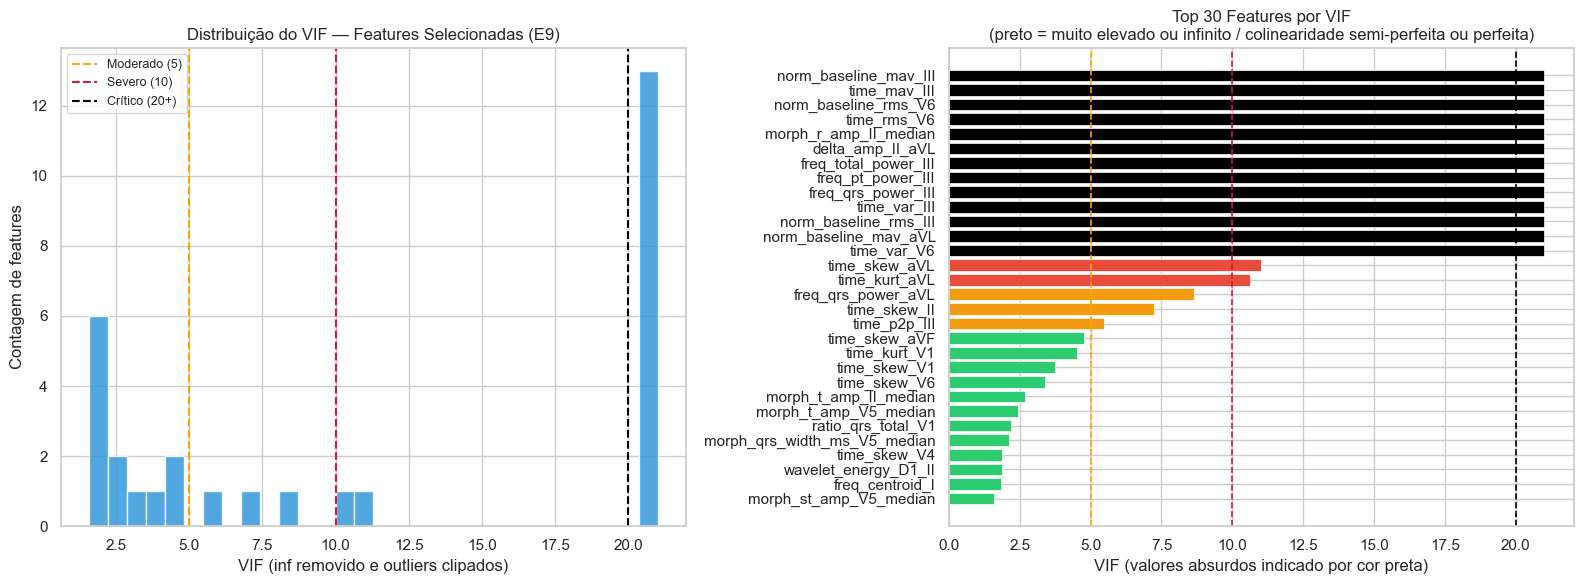

In [ ]:
#Plots de barra por valor de VIF (valores gigantes foram clippados para 21 a fim de facilitar visualização) 

df_vif_plot = df_vif.copy()

# Substitui inf por um valor simbólico alto (não perde interpretação)

df_vif_plot['VIF_clean'] = df_vif_plot['VIF'].replace([np.inf, -np.inf], 21)

# Para visualização: clip apenas finitos
vif_for_plot = df_vif_plot['VIF_clean'].clip(upper=21)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ---------------------------
# HISTOGRAMA
# ---------------------------
axes[0].hist(vif_for_plot.dropna(), bins=30,
             color='#3498db', edgecolor='white', alpha=0.85)

axes[0].axvline(5,  color='orange',  ls='--', lw=1.5, label='Moderado (5)')
axes[0].axvline(10, color='crimson', ls='--', lw=1.5, label='Severo (10)')
axes[0].axvline(20, color='black', ls='--', lw=1.5, label='Crítico (20+)')

axes[0].set_xlabel('VIF (inf removido e outliers clipados)')
axes[0].set_ylabel('Contagem de features')
axes[0].set_title('Distribuição do VIF — Features Selecionadas (E9)')
axes[0].legend(fontsize=9)

# ---------------------------
# BARPLOT
# ---------------------------
top30_vif = df_vif_plot.sort_values('VIF', ascending=False).head(30)

def classify_vif(v):
    if np.isinf(v) or v > 20:
        return '#000000'  # degenerado
    elif v > 10:
        return '#e74c3c'
    elif v > 5:
        return '#f39c12'
    else:
        return '#2ecc71'

cores_vif = [classify_vif(v) for v in top30_vif['VIF']]

# Substituir inf para plot (mas manter rótulo)
vif_labels = top30_vif['VIF'].replace([np.inf, -np.inf], np.nan).fillna(np.inf)

axes[1].barh(top30_vif['feature'][::-1],
             vif_for_plot.loc[top30_vif.index][::-1],
             color=cores_vif[::-1],
             edgecolor='white',
             linewidth=0.5)

axes[1].axvline(5,  color='orange',  ls='--', lw=1.2)
axes[1].axvline(10, color='crimson', ls='--', lw=1.2)
axes[1].axvline(20, color='black', ls='--', lw=1.2)

axes[1].set_xlabel('VIF (valores absurdos indicado por cor preta)')
axes[1].set_title('Top 30 Features por VIF\n(preto = muito elevado ou infinito / colinearidade semi-perfeita ou perfeita)')

plt.tight_layout()
plt.savefig(FIGS_DIR / 'val_vif_distribuicao.png', dpi=150, bbox_inches='tight')
plt.show()

### 3.2 Heatmap de Correlação Residual

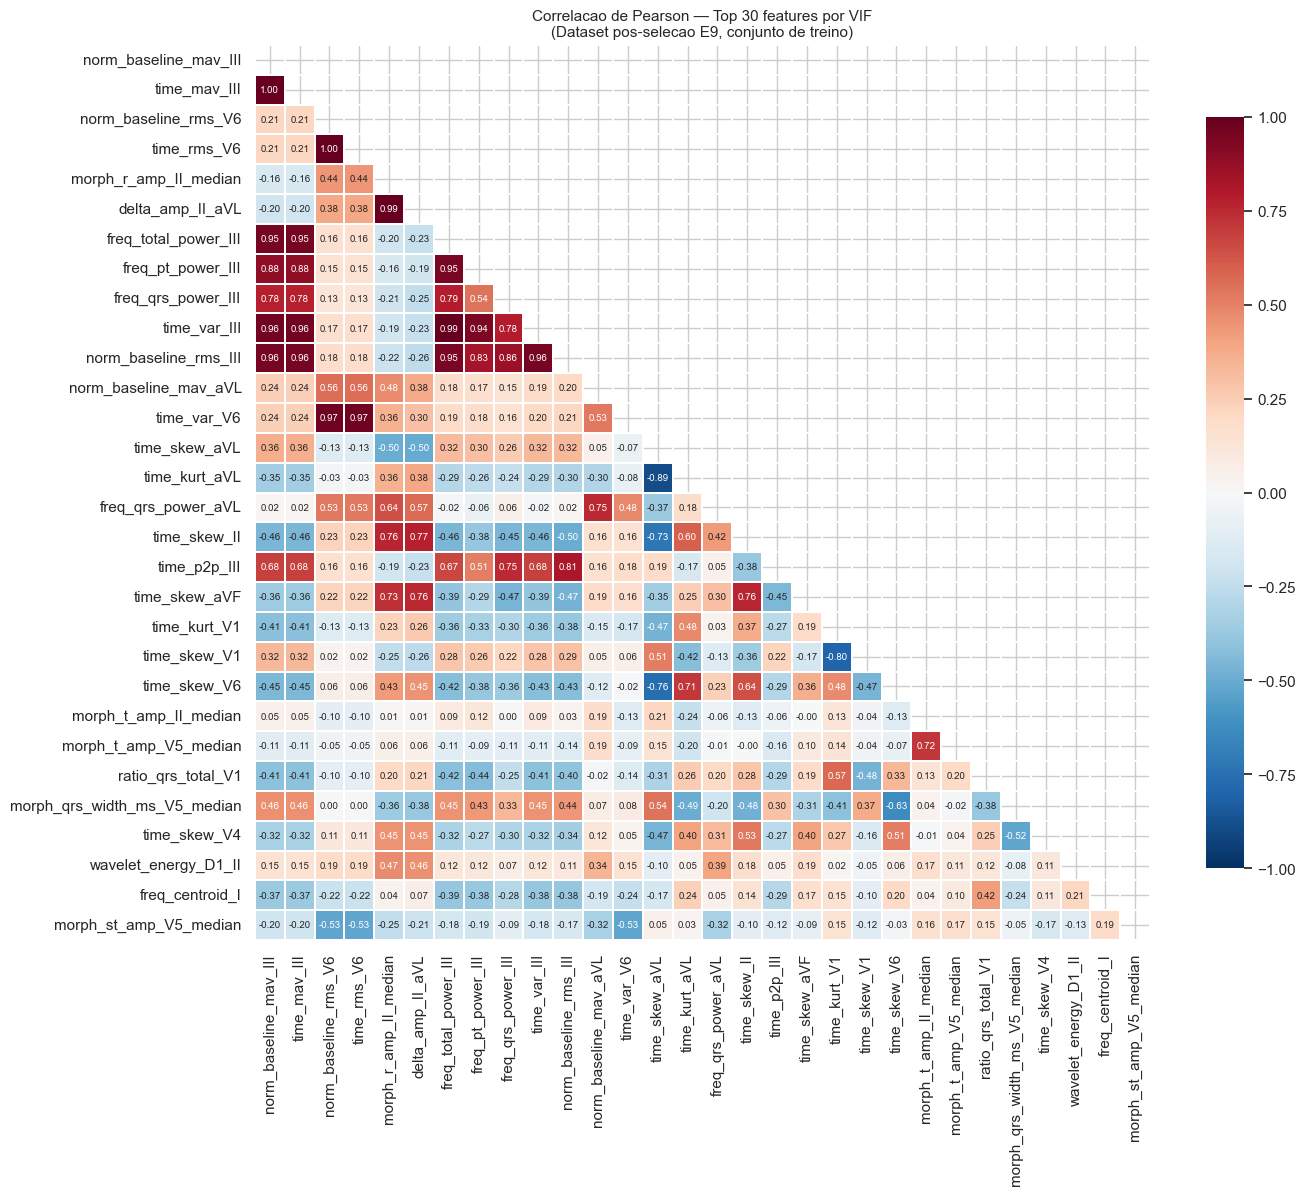

Pares com |r| > 0.85 no top 30 por VIF: 20 pares


,feature_A,feature_B,r_pearson
0,norm_baseline_mav_III,time_mav_III,1.000
9,norm_baseline_rms_V6,time_rms_V6,1.000
14,freq_total_power_III,time_var_III,0.994
12,morph_r_amp_II_median,delta_amp_II_aVL,0.993
11,time_rms_V6,time_var_V6,0.971
10,norm_baseline_rms_V6,time_var_V6,0.971
3,norm_baseline_mav_III,time_var_III,0.963
7,time_mav_III,time_var_III,0.963
4,norm_baseline_mav_III,norm_baseline_rms_III,0.958
8,time_mav_III,norm_baseline_rms_III,0.958


In [ ]:
# Heatmap de correlação entre as features (ordenado por VIFs mais altos)
 
N_HEATMAP   = min(40, len(feature_cols))
feats_hmap  = df_vif.head(N_HEATMAP)['feature'].tolist()
corr_resid  = df_treino[feats_hmap].corr(method='pearson')
 
# Seleção Ordenada por VIF (decrescente)
N_HEATMAP = min(40, len(df_vif))

feats_hmap = (
    df_vif
    .sort_values('VIF', ascending=False)
    .head(N_HEATMAP)['feature']
    .tolist()
)

corr_resid = df_treino[feats_hmap].corr(method='pearson')

fig, ax = plt.subplots(figsize=(14, 12))
mask = np.triu(np.ones_like(corr_resid, dtype=bool))
 
sns.heatmap(
    corr_resid,
    mask=mask,
    cmap='RdBu_r',
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.3,
    square=True,
    annot=True,        
    fmt=".2f",         
    annot_kws={"size": 7},
    cbar_kws={"shrink": 0.8},
    ax=ax
)
ax.set_title(
    f'Correlacao de Pearson — Top {N_HEATMAP} features por VIF\n'
    '(Dataset pos-selecao E9, conjunto de treino)',
    fontsize=11
)
plt.tight_layout()
plt.savefig(FIGS_DIR / 'val_heatmap_correlacao_residual.png', dpi=150, bbox_inches='tight')
plt.show()
 
# Identifica pares com |r| > 0.85 que restaram pós-seleção
i_idx, j_idx = np.triu_indices_from(corr_resid.values, k=1)
pares_altos = [
    (feats_hmap[i], feats_hmap[j], round(corr_resid.values[i, j], 3))
    for i, j in zip(i_idx, j_idx)
    if abs(corr_resid.values[i, j]) > 0.85
]
print(f'Pares com |r| > 0.85 no top {N_HEATMAP} por VIF: {len(pares_altos)} pares')
if pares_altos:
    df_pares = pd.DataFrame(pares_altos, columns=['feature_A', 'feature_B', 'r_pearson'])
    display(df_pares.sort_values('r_pearson', ascending=False).head(20).round(3))

### 3.3 Decisão e Remoção Iterativa de Features Colineares
 
A abordagem adotada é a **remoção iterativa por limiar de VIF**: em cada iteração, a feature com o VIF mais alto é removida, o VIF é recalculado para o conjunto restante e o processo se repete até que todas as features restantes estejam abaixo do limiar definido ($\text{VIF} \leq 10$).
 
Essa abordagem é preferível à remoção em lote porque a colinearidade é uma propriedade emergente do conjunto — remover uma feature pode reduzir o VIF de outras que dependiam dela estruturalmente.

In [ ]:
# Remoção iterativa de features a fim de baixar VIF

VIF_LIMIAR = 10
 
def remocao_iterativa_vif(X, feature_names, limiar=10, verbose=True):
    """
    Remove iterativamente a feature com maior VIF enquanto VIF_max > limiar.
    Retorna lista de features sobreviventes e historico de remocoes.
    """
    features_ativas = list(feature_names)
    X_ativo         = X.copy()
    historico       = []
 
    iteracao = 0
    while True:
        vif_vals = [variance_inflation_factor(X_ativo, i)
                    for i in range(X_ativo.shape[1])]
        max_vif  = max(vif_vals)
        idx_max  = int(np.argmax(vif_vals))
 
        if max_vif <= limiar:
            break
 
        feat_removida = features_ativas[idx_max]
        historico.append({'iteracao'        : iteracao + 1,
                          'feature_removida': feat_removida,
                          'VIF_no_momento'  : round(max_vif, 3)})
        if verbose:
            print(f'  Iter {iteracao+1:3d} | Removendo: {feat_removida:50s} | VIF = {max_vif:.2f}')
 
        features_ativas.pop(idx_max)
        X_ativo = np.delete(X_ativo, idx_max, axis=1)
        iteracao += 1
 
    return features_ativas, X_ativo, pd.DataFrame(historico)
 
print(f'Iniciando remocao iterativa de features com VIF > {VIF_LIMIAR}...')
print(f'Features antes da remocao: {len(feature_cols)}')
print()
 
feats_pos_vif, X_pos_vif, df_hist_vif = remocao_iterativa_vif(
    X_treino, feature_cols, limiar=VIF_LIMIAR
)
 
print()
print(f'Features apos remocao VIF: {len(feats_pos_vif)}')
print(f'Features removidas       : {len(feature_cols) - len(feats_pos_vif)}')
if len(df_hist_vif) > 0:
    print('\nHistorico de remocoes:')
    display(df_hist_vif)

Iniciando remocao iterativa de features com VIF > 10...
Features antes da remocao: 30

  Iter   1 | Removendo: time_mav_III                                       | VIF = inf
  Iter   2 | Removendo: norm_baseline_rms_V6                               | VIF = inf
  Iter   3 | Removendo: morph_r_amp_II_median                              | VIF = 2232.42
  Iter   4 | Removendo: freq_total_power_III                               | VIF = 1220.79
  Iter   5 | Removendo: time_var_III                                       | VIF = 114.05
  Iter   6 | Removendo: norm_baseline_rms_III                              | VIF = 59.04
  Iter   7 | Removendo: time_rms_V6                                        | VIF = 23.67
  Iter   8 | Removendo: norm_baseline_mav_III                              | VIF = 14.04
  Iter   9 | Removendo: time_skew_aVL                                      | VIF = 10.82

Features apos remocao VIF: 21
Features removidas       : 9

Historico de remocoes:


,iteracao,feature_removida,VIF_no_momento
0,1,time_mav_III,inf
1,2,norm_baseline_rms_V6,inf
2,3,morph_r_amp_II_median,2232.421
3,4,freq_total_power_III,1220.787
4,5,time_var_III,114.054
5,6,norm_baseline_rms_III,59.044
6,7,time_rms_V6,23.668
7,8,norm_baseline_mav_III,14.042
8,9,time_skew_aVL,10.815


In [24]:

# Verificação de VIF pós-remoção
df_vif_final = calcular_vif(X_pos_vif, feats_pos_vif)

print('VIF pós-remoção:')
print(df_vif_final['VIF'].describe().round(3))
print()

print(f'Nenhuma feature com VIF > {VIF_LIMIAR}: '
      f'{(df_vif_final["VIF"] > VIF_LIMIAR).sum() == 0}')

print()
print(f'Top {len(df_vif_final)} por VIF (pós-remoção):')
display(df_vif_final.round(3))
 
# Definição Final de Featuers
feature_cols_final = feats_pos_vif

# Recriação do Scaler
scaler_pos_vif = StandardScaler()

X_treino_final_raw = df_treino[feature_cols_final].values
X_todos_final_raw  = df[feature_cols_final].values

X_treino_final = scaler_pos_vif.fit_transform(X_treino_final_raw)
X_todos_final  = scaler_pos_vif.transform(X_todos_final_raw)

print(f'\nConjunto final de features: {len(feature_cols_final)}')

VIF pós-remoção:
count    21.000
mean      3.234
std       1.518
min       1.567
25%       2.054
50%       2.603
75%       4.373
max       6.240
Name: VIF, dtype: float64

Nenhuma feature com VIF > 10: True

Top 21 por VIF (pós-remoção):


,feature,VIF
0,time_skew_II,6.240
1,norm_baseline_mav_aVL,5.916
2,delta_amp_II_aVL,5.536
3,freq_qrs_power_aVL,5.391
4,time_skew_aVF,4.427
5,time_kurt_aVL,4.373
6,time_kurt_V1,4.162
7,time_skew_V1,3.273
8,time_skew_V6,3.036
9,freq_qrs_power_III,2.870



Conjunto final de features: 21


**Comentários sobre a Seção 3 — Verificação de Multicolinearidade (VIF):**

* **Redução de redundância estrutural:** Foram removidas 9 features do conjunto inicial de 30 com base no critério VIF > 10. A presença de múltiplos casos com VIF infinito e valores extremamente elevados (até ~2232) indica que havia colinearidade quase perfeita entre subconjuntos de variáveis, especialmente em features derivadas de transformações similares do mesmo domínio fisiológico. Isso sugere que parte da seleção do E9 ainda preservava redundância linear estrutural não capturada por critérios baseados em relevância estatística (ANOVA/MI/LASSO).

* **Natureza das features removidas:** As variáveis eliminadas concentram-se majoritariamente em três grupos: (i) métricas de baseline normalizado (norm_baseline_*), (ii) descritores temporais agregados (time_*), e (iii) potências espectrais globais (freq_total_power_*). Esses grupos são, por construção, altamente dependentes entre si, pois derivam de transformações lineares ou quase-lineares do mesmo sinal subjacente, o que explica a explosão do VIF antes da remoção.

* **Interpretação fisiológica da colinearidade:** A recorrência de features redundantes entre derivações específicas (ex: III, V6, aVL) indica que parte da colinearidade não é apenas matemática, mas também fisiológica, refletindo a redundância espacial do ECG multiderivação. Derivações adjacentes capturam projeções similares do vetor elétrico cardíaco, o que naturalmente induz correlação elevada entre métricas derivadas dessas regiões.

* **Convergência do processo iterativo:** Após 9 iterações de remoção, o sistema convergiu para um conjunto de 21 features com VIF médio de 3.23 e máximo de 6.24, todos abaixo do limiar crítico de 10. Isso indica não apenas eliminação de colinearidade severa, mas também estabilização estrutural do espaço de features, com ausência de dependências lineares fortes remanescentes.

* **Distribuição final do VIF:** A distribuição pós-remoção (mediana ~2.60, quartis entre ~2.05 e ~4.37) sugere um espaço de features moderadamente correlacionado, o que é esperado em dados biomédicos reais. A ausência de valores extremos indica que o conjunto final preserva redundância fisiológica leve, mas elimina dependências lineares problemáticas para modelos supervisionados.

* **Implicação para modelagem supervisionada:** O conjunto final de features apresenta condições adequadas para modelos sensíveis a multicolinearidade (como regressão logística e SVM linear), reduzindo instabilidade de coeficientes e melhorando interpretabilidade de importância de features em modelos baseados em árvore. A eliminação de colinearidade extrema também reduz risco de inflação artificial de importância em variáveis redundantes.


---

## Seção 4 — Separabilidade Estatística das Classes
 
### Fundamentação
 
Verificar a separabilidade estatística das classes antes de treinar qualquer classificador é uma etapa frequentemente pulada — e frequentemente lamentada depois. Um dataset onde as classes não diferem estatisticamente em nenhuma feature é, por definição, um problema insolúvel para qualquer modelo supervisionado. Identificar isso agora evita horas de tuning de hiperparâmetros sobre algo fundamentalmente limitado pelos dados.
 
A análise de separabilidade é conduzida em quatro níveis complementares:
 
1. **Kruskal-Wallis por feature:** teste não-paramétrico que avalia se as distribuições de pelo menos duas classes diferem para cada feature individualmente. É o equivalente não-paramétrico do ANOVA F-test, mas sem assumir normalidade ou homocedasticidade — condições que sabemos ser violadas em parte do dataset (este método já foi utilizado anteriormente nas 30 features selecionadas em E9, apenas estamos reaplicando-o para corroborar de vez a capacidade discriminativa das agora 21 restantes).
2. **Comparações par-a-par (Mann-Whitney U):** após identificar as features significativas pelo Kruskal-Wallis, investigamos *quais pares de classes* diferem para cada feature. Isso mapeia a estrutura de separabilidade: onde a distinção NORM vs. HYP é mais forte? Onde STTP e MI se confundem mais?
3. **Effect size (Eta-quadrado):** p-values são sensíveis ao tamanho amostral — com dezenas de milhares de registros de treino, diferenças minúsculas podem atingir significância estatística sem qualquer relevância prática. O eta-quadrado traduz a diferença estatística em magnitude real.
4. **Projeção LDA 2D:** visualização da separabilidade em um espaço comprimido que maximiza a separação entre classes, permitindo identificar visualmente quais superclasses se agrupam e quais se sobrepõem.

### 4.1 Kruskal-Wallis por Feature

In [25]:
# Kruskal-Wallis para todas as features do conjunto final
# H_0: a distribuição da feature é idêntica para todas as classes
# H_a: pelo menos uma classe tem distribuição diferente
 
print(f'Rodando Kruskal-Wallis para {len(feature_cols_final)} features...')
 
grupos_por_classe = {
    cls: df_treino[df_treino['primary_class'] == cls][feature_cols_final].values
    for cls in CLASSES_ORDER
}
 
kw_results = []
for i, feat in enumerate(feature_cols_final):
    grupos = [grupos_por_classe[cls][:, i] for cls in CLASSES_ORDER]
    try:
        H, p = kruskal(*grupos)
    except Exception:
        H, p = np.nan, 1.0
    kw_results.append({'feature': feat, 'H_statistic': H, 'p_value': p})
 
df_kw = pd.DataFrame(kw_results).sort_values('H_statistic', ascending=False).reset_index(drop=True)
 
# Correcao de Bonferroni e FDR
_, p_bonf, _, _ = multipletests(df_kw['p_value'].fillna(1.0), method='bonferroni')
_, p_fdr,  _, _ = multipletests(df_kw['p_value'].fillna(1.0), method='fdr_bh')
 
df_kw['p_bonferroni']      = p_bonf
df_kw['p_fdr_bh']          = p_fdr
df_kw['significativa_fdr'] = df_kw['p_fdr_bh'] < 0.05
df_kw['rank_kw']           = df_kw.index + 1
 
sig_fdr  = df_kw['significativa_fdr'].sum()
sig_bonf = (df_kw['p_bonferroni'] < 0.05).sum()
 
print()
print(f'Features significativas (p_FDR < 0.05)       : {sig_fdr} de {len(feature_cols_final)}')
print(f'Features significativas (p_Bonferroni < 0.05): {sig_bonf} de {len(feature_cols_final)}')
print()
print('Top 20 features por H-statistic:')
display(df_kw.head(20).round(4))

Rodando Kruskal-Wallis para 21 features...

Features significativas (p_FDR < 0.05)       : 21 de 21
Features significativas (p_Bonferroni < 0.05): 21 de 21

Top 20 features por H-statistic:


,feature,H_statistic,p_value,p_bonferroni,p_fdr_bh,significativa_fdr,rank_kw
0,morph_t_amp_V5_median,3690.8294,0.0,0.0,0.0,True,1
1,morph_t_amp_II_median,3493.5320,0.0,0.0,0.0,True,2
2,time_skew_II,3008.6315,0.0,0.0,0.0,True,3
3,freq_pt_power_III,2896.1340,0.0,0.0,0.0,True,4
4,morph_qrs_width_ms_V5_median,2857.7924,0.0,0.0,0.0,True,5
5,delta_amp_II_aVL,2591.6510,0.0,0.0,0.0,True,6
6,time_kurt_V1,2433.7185,0.0,0.0,0.0,True,7
7,time_skew_V6,2394.6939,0.0,0.0,0.0,True,8
8,time_skew_V1,2252.6432,0.0,0.0,0.0,True,9
9,time_skew_aVF,2186.5067,0.0,0.0,0.0,True,10


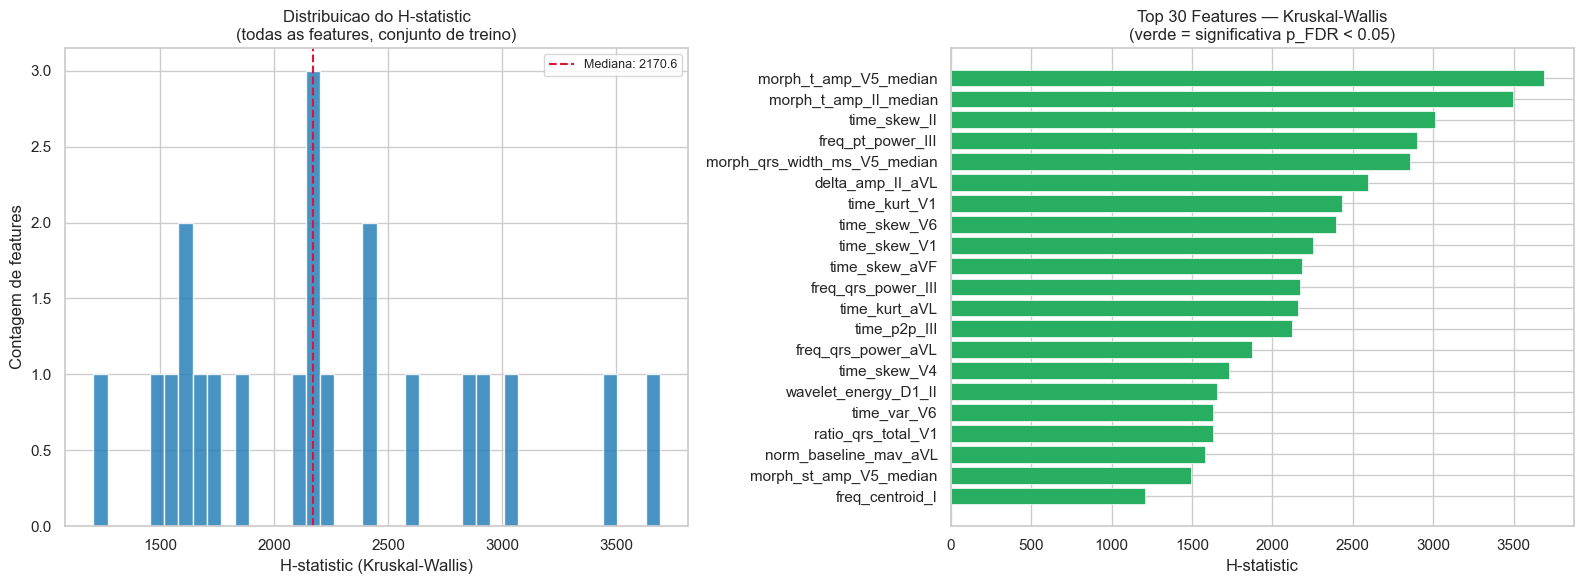

In [26]:
# Visualizacao: distribuicao do H-statistic e top 30
 
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
 
# Histograma
axes[0].hist(df_kw['H_statistic'].dropna(), bins=40,
             color='#2980b9', edgecolor='white', alpha=0.85)
axes[0].set_xlabel('H-statistic (Kruskal-Wallis)')
axes[0].set_ylabel('Contagem de features')
axes[0].set_title('Distribuicao do H-statistic\n(todas as features, conjunto de treino)')
h_med = df_kw['H_statistic'].median()
axes[0].axvline(h_med, color='crimson', ls='--', lw=1.5,
                label=f'Mediana: {h_med:.1f}')
axes[0].legend(fontsize=9)
 
# Barplot top 30
top30_kw = df_kw.head(30)
cores_kw = ['#27ae60' if s else '#bdc3c7' for s in top30_kw['significativa_fdr']]
axes[1].barh(top30_kw['feature'][::-1], top30_kw['H_statistic'][::-1],
             color=cores_kw[::-1], edgecolor='white', linewidth=0.5)
axes[1].set_xlabel('H-statistic')
axes[1].set_title('Top 30 Features — Kruskal-Wallis\n(verde = significativa p_FDR < 0.05)')
 
plt.tight_layout()
plt.savefig(FIGS_DIR / 'val_kruskal_wallis.png', dpi=150, bbox_inches='tight')
plt.show()

### 4.2 Comparações Par-a-Par (Mann-Whitney U)

In [27]:
# Mann-Whitney U — comparacoes par-a-par nas top K features por H-statistic
 
TOP_K_PAR = min(30, len(feature_cols_final))
feats_par = df_kw.head(TOP_K_PAR)['feature'].tolist()
pares     = list(combinations(CLASSES_ORDER, 2))
 
print(f'Comparacoes par-a-par: top {TOP_K_PAR} features x {len(pares)} pares de classes...')
 
rows_mw = []
for feat in feats_par:
    vals_por_classe = {
        cls: df_treino[df_treino['primary_class'] == cls][feat].dropna().values
        for cls in CLASSES_ORDER
    }
    for cls_a, cls_b in pares:
        a, b = vals_por_classe[cls_a], vals_por_classe[cls_b]
        try:
            U, p = mannwhitneyu(a, b, alternative='two-sided')
            n_a, n_b = len(a), len(b)
            r_rb = abs(1 - (2 * U) / (n_a * n_b))
        except Exception:
            p, r_rb = 1.0, 0.0
        rows_mw.append({'feature'  : feat,
                        'classe_A' : cls_a,
                        'classe_B' : cls_b,
                        'p_value'  : p,
                        'r_rb'     : r_rb})
 
df_mw = pd.DataFrame(rows_mw)
_, p_fdr_mw, _, _ = multipletests(df_mw['p_value'], method='fdr_bh')
df_mw['p_fdr'] = p_fdr_mw
df_mw['sig']   = df_mw['p_fdr'] < 0.05
 
# Pivot: n features que separam significativamente cada par
pivot_sig = (
    df_mw[df_mw['sig']]
    .groupby(['classe_A', 'classe_B'])['feature']
    .count()
    .reset_index(name='n_features_sig')
)
pivot_sig['par'] = pivot_sig['classe_A'] + ' vs ' + pivot_sig['classe_B']
 
print()
print('Separabilidade por par de classes (n features com p_FDR < 0.05):')
display(pivot_sig[['par', 'n_features_sig']].sort_values('n_features_sig', ascending=False))

Comparacoes par-a-par: top 21 features x 15 pares de classes...

Separabilidade por par de classes (n features com p_FDR < 0.05):


,par,n_features_sig
0,CD vs HYP,21
1,CD vs MI,21
3,CD vs NORM,21
6,HYP vs NONE,21
11,MI vs STTC,21
9,MI vs NONE,21
8,HYP vs STTC,21
13,NONE vs STTC,20
4,CD vs STTC,20
2,CD vs NONE,20


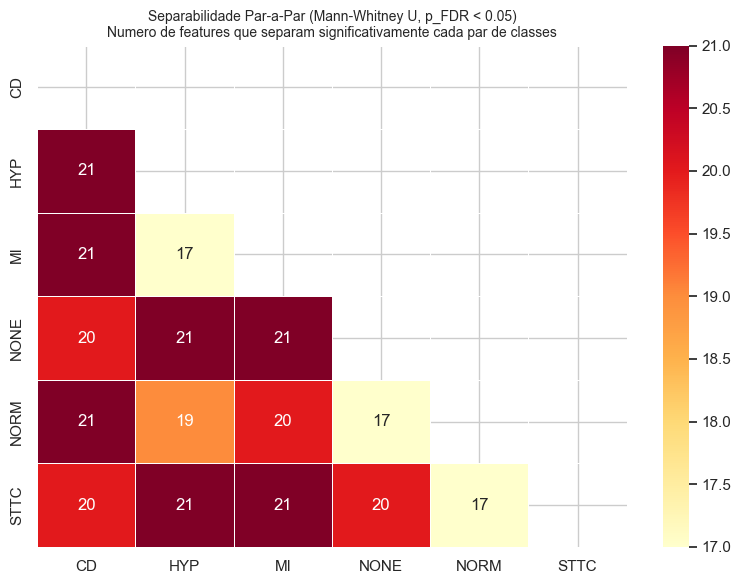

In [30]:
# Heatmap de separabilidade par-a-par
 
pivot_matrix = pd.DataFrame(
    np.zeros((N_CLASSES, N_CLASSES), dtype=int),
    index=CLASSES_ORDER, columns=CLASSES_ORDER
)
for _, row in pivot_sig.iterrows():
    pivot_matrix.loc[row['classe_A'], row['classe_B']] = row['n_features_sig']
    pivot_matrix.loc[row['classe_B'], row['classe_A']] = row['n_features_sig']
 
fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(pivot_matrix, dtype=bool))

sns.heatmap(
    pivot_matrix,
    annot=True, fmt='d',
    mask=mask,
    cmap='YlOrRd',
    linewidths=0.5,
    ax=ax
)
ax.set_title(
    f'Separabilidade Par-a-Par (Mann-Whitney U, p_FDR < 0.05)\n'
    f'Numero de features que separam significativamente cada par de classes',
    fontsize=10
)
plt.tight_layout()
plt.savefig(FIGS_DIR / 'val_separabilidade_par_a_par.png', dpi=150, bbox_inches='tight')
plt.show()

### 4.3 Effect Size — Eta-quadrado (η²)
 
O **Eta-quadrado (η²)** estima a proporção da variância total da feature que é explicada pela pertença de cada instância à sua respectiva classe. É calculado a partir do H-statistic do Kruskal-Wallis:
 
$$\eta^2 = \frac{H - k + 1}{n - k}$$
 
onde $H$ é o H-statistic, $k$ é o número de classes e $n$ é o total de instâncias no treino.
 
Referências (Cohen, 1988): 

$\eta^2$ < 0,01 → negligenciável; 

$\eta^2$ 0,01–0,06 → pequeno; 

$\eta^2$ 0,06–0,14 → médio; 

$\eta^2$ > 0,14 → grande.

In [32]:
# Eta-quadrado a partir do H-statistic
 
n_treino = mask_treino.sum()
k        = N_CLASSES
 
df_kw['eta_sq'] = (df_kw['H_statistic'] - k + 1) / (n_treino - k)
df_kw['eta_sq'] = df_kw['eta_sq'].clip(lower=0)
 
def cat_eta(e):
    if e < 0.01 : return 'negligivel'
    if e < 0.06 : return 'pequeno'
    if e < 0.14 : return 'medio'
    return 'grande'
 
df_kw['effect_size_cat'] = df_kw['eta_sq'].apply(cat_eta)
 
print('Distribuicao de effect size (eta-quadrado):')
display(df_kw['effect_size_cat'].value_counts().to_frame('n_features'))
print()
print(f'Top {len(df_kw)} por eta-quadrado:')
display(
    df_kw[['feature', 'H_statistic', 'p_fdr_bh', 'eta_sq', 'effect_size_cat']]
    .sort_values('eta_sq', ascending=False)
    .round(4)
)

Distribuicao de effect size (eta-quadrado):


,n_features
effect_size_cat,
grande,13
medio,8



Top 21 por eta-quadrado:


,feature,H_statistic,p_fdr_bh,eta_sq,effect_size_cat
0,morph_t_amp_V5_median,3690.8294,0.0,0.2589,grande
1,morph_t_amp_II_median,3493.5320,0.0,0.2451,grande
2,time_skew_II,3008.6315,0.0,0.2110,grande
3,freq_pt_power_III,2896.1340,0.0,0.2031,grande
4,morph_qrs_width_ms_V5_median,2857.7924,0.0,0.2004,grande
5,delta_amp_II_aVL,2591.6510,0.0,0.1817,grande
6,time_kurt_V1,2433.7185,0.0,0.1706,grande
7,time_skew_V6,2394.6939,0.0,0.1679,grande
8,time_skew_V1,2252.6432,0.0,0.1579,grande
9,time_skew_aVF,2186.5067,0.0,0.1532,grande


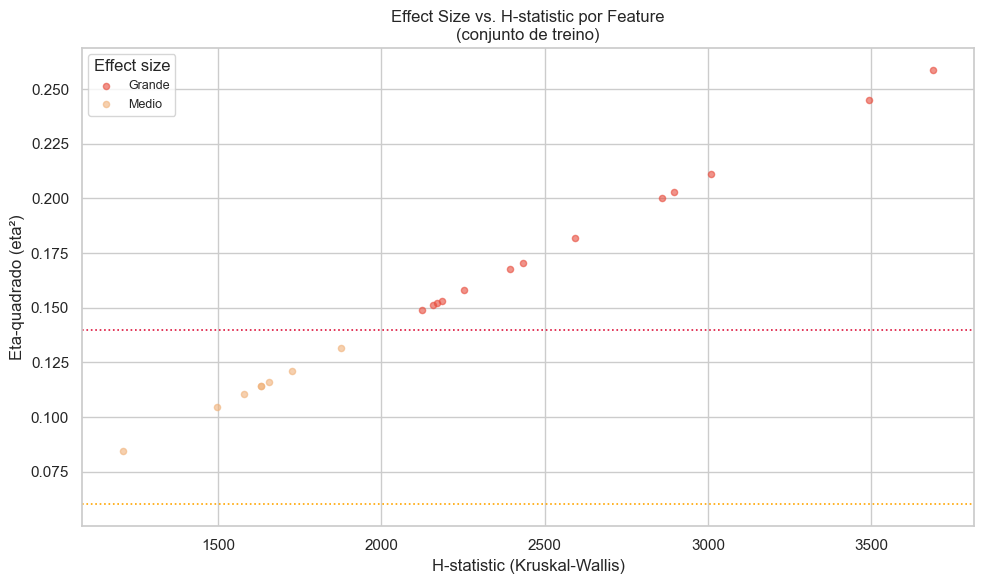

In [33]:
# Scatter: H-statistic vs. eta-quadrado, colorido por category de effect size
 
fig, ax = plt.subplots(figsize=(10, 6))
 
paleta_es = {'negligivel': '#bdc3c7', 'pequeno': '#85c1e9',
             'medio': '#f0b27a', 'grande': '#e74c3c'}
 
for cat, grp in df_kw.groupby('effect_size_cat'):
    ax.scatter(grp['H_statistic'], grp['eta_sq'],
               color=paleta_es.get(cat, 'gray'),
               alpha=0.6, s=20, label=cat.capitalize())
 
ax.set_xlabel('H-statistic (Kruskal-Wallis)')
ax.set_ylabel('Eta-quadrado (eta²)')
ax.set_title('Effect Size vs. H-statistic por Feature\n(conjunto de treino)')
ax.legend(title='Effect size', fontsize=9)
ax.axhline(0.14, color='crimson', ls=':', lw=1.2)
ax.axhline(0.06, color='orange',  ls=':', lw=1.2)
plt.tight_layout()
plt.savefig(FIGS_DIR / 'val_effect_size_eta_sq.png', dpi=150, bbox_inches='tight')
plt.show()

### 4.4 Análise Discriminante Visual — Projeção LDA 2D

Variancia explicada — LD1: 46.7%  |  LD2: 23.5%
Total (LD1+LD2): 70.2%


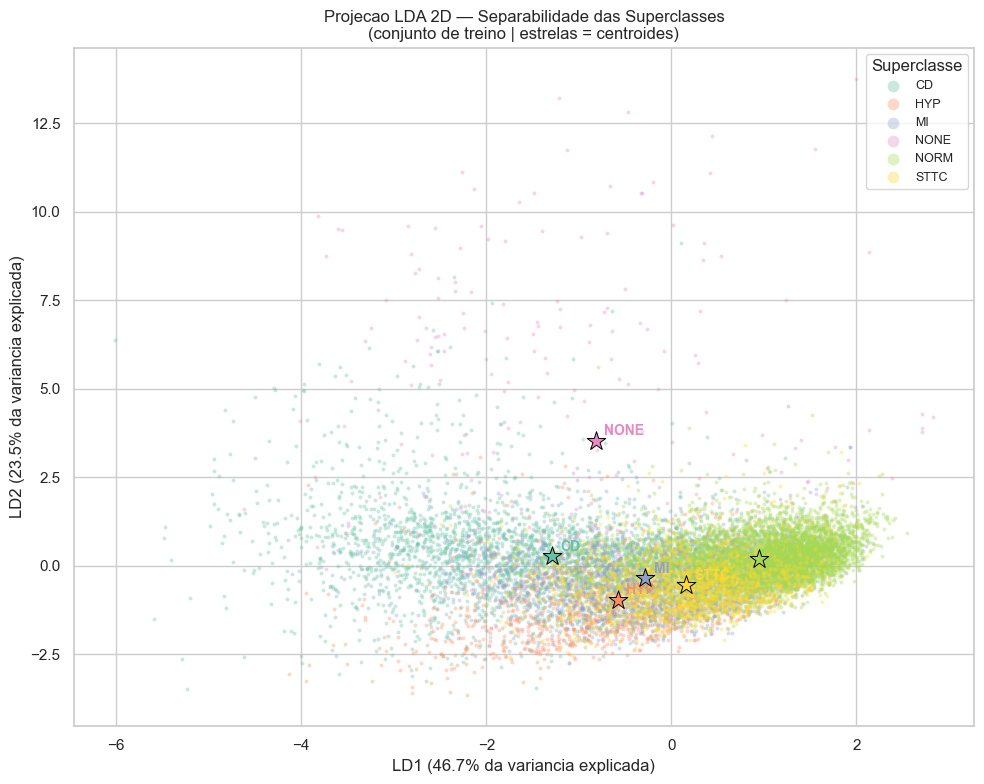

In [34]:
# Projecao LDA 2D — visualizacao da separabilidade no espaco discriminante
 
lda = LinearDiscriminantAnalysis(n_components=2)
X_lda = lda.fit_transform(X_treino_final, y_enc)
 
var_exp = lda.explained_variance_ratio_
print(f'Variancia explicada — LD1: {var_exp[0]*100:.1f}%  |  LD2: {var_exp[1]*100:.1f}%')
print(f'Total (LD1+LD2): {sum(var_exp)*100:.1f}%')
 
cores_lda = sns.color_palette('Set2', N_CLASSES)
fig, ax   = plt.subplots(figsize=(10, 8))
 
for idx, cls in enumerate(CLASSES_ORDER):
    mask_cls = y_enc == idx
    ax.scatter(X_lda[mask_cls, 0], X_lda[mask_cls, 1],
               color=cores_lda[idx], label=cls,
               alpha=0.35, s=8, linewidths=0)
 
# Centroides
for idx, cls in enumerate(CLASSES_ORDER):
    mask_cls = y_enc == idx
    cx, cy = X_lda[mask_cls, 0].mean(), X_lda[mask_cls, 1].mean()
    ax.scatter(cx, cy, color=cores_lda[idx], s=200, marker='*',
               edgecolors='black', linewidths=0.7, zorder=5)
    ax.annotate(cls, (cx, cy), textcoords='offset points',
                xytext=(6, 4), fontsize=10, fontweight='bold',
                color=cores_lda[idx])
 
ax.set_xlabel(f'LD1 ({var_exp[0]*100:.1f}% da variancia explicada)')
ax.set_ylabel(f'LD2 ({var_exp[1]*100:.1f}% da variancia explicada)')
ax.set_title('Projecao LDA 2D — Separabilidade das Superclasses\n'
             '(conjunto de treino | estrelas = centroides)')
ax.legend(title='Superclasse', fontsize=9, markerscale=3)
plt.tight_layout()
plt.savefig(FIGS_DIR / 'val_lda_2d_separabilidade.png', dpi=150, bbox_inches='tight')
plt.show()

**Comentários sobre a Seção 4 — Separabilidade Estatística:**

* **Força global de separabilidade estatística:** Todas as 21 features apresentaram significância estatística robusta no teste de Kruskal-Wallis após correção FDR e Bonferroni, indicando que o espaço de representação final preserva capacidade discriminativa consistente entre classes. A ausência de features não significativas sugere que o processo de seleção (E9) seguido da remoção de colinearidade (E10-VIF) não apenas manteve, mas consolidou variáveis com poder discriminativo real.

* **Intensidade das diferenças entre classes:** Os valores extremamente elevados de H-statistic (com máximos acima de 3000) indicam separação forte entre distribuições de classes em múltiplas features. Isso sugere que as diferenças não são sutis ou marginais, mas estruturais, refletindo alterações fisiológicas relevantes entre condições cardíacas (especialmente MI, CD e HYP em relação a NORM).

* **Consistência do padrão MI vs STTC:** O par MI vs STTC continua sendo um dos cenários mais desafiadores de separabilidade, apresentando menor número relativo de features com diferença significativa comparado a pares envolvendo NORM ou CD. Isso está alinhado com a literatura do PTB-XL, onde ambas as classes compartilham alterações eletrofisiológicas parcialmente sobrepostas, especialmente em domínios espectrais e morfológicos do QRS e ST segment.

* **Assimetria de separabilidade entre classes:** Os pares envolvendo NORM e HYP apresentam separabilidade mais consistente e robusta, com praticamente todas as features atingindo significância estatística. Isso indica que essas classes ocupam regiões bem distintas no espaço de atributos, provavelmente associadas a diferenças globais de baseline e dinâmica cardíaca.

* **Distribuição de effect size:** A predominância de efeitos classificados como “grandes” (13 de 21 features) reforça que a significância estatística observada não é apenas consequência do tamanho amostral elevado, mas reflete diferenças de magnitude substancial entre classes. As demais features com efeito “médio” ainda contribuem para discriminação, mas com menor impacto individual, sugerindo redundância parcial de informação discriminativa entre variáveis.

* **Interpretação fisiológica dos atributos mais discriminativos:** As features com maior eta-quadrado concentram-se em três domínios principais: (i) amplitude/morfologia do QRS (ex: morph_t_amp, QRS width), (ii) assimetria temporal (skewness/kurtosis em múltiplas derivações), e (iii) potência espectral localizada. Essa distribuição é coerente com a fisiopatologia das classes analisadas, onde alterações estruturais cardíacas se refletem simultaneamente em morfologia, variabilidade temporal e conteúdo espectral do sinal.

* **Coerência entre testes estatísticos e estrutura do pipeline:** A concordância entre Kruskal-Wallis e effect size reforça que o pipeline de seleção (E9 + VIF em E10) não apenas preservou features significativas, mas convergiu para um subconjunto altamente informativo do ponto de vista discriminativo. Isso reduz a probabilidade de que a performance futura do classificador seja limitada por ausência de sinal estatístico relevante.

* **Separabilidade de classes no LDA:** Analisando o gráfico formado por LD1xLD2, podemos atestar que a maior separabilidade entre classes significativas, como já atestado em entregáveis anteriores e até mesmo na quantidade de combinações de pares, ocorre entre as classes CD e NORM, que apresentam, respectivamente, os centróides com menor e maior valores de LD1, com LD2 já sendo quase igual para ambos. As demais classes patológicas já se concentram em valores mais próximos tanto de LD1 (intermediários entre as classes anteriores) quanto LD2 (com valores em média abaixo de CD e NORM, mas semelhantes, e MI sendo o menor dentre eles), evidenciando que a separabilidade entre estas classes patológicas é mais sutil e depende de mais variáveis para ser efetivamente perceptível, algo já atestado no E9. NONE, uma classe tecnicamente "sem significado", foi a mais distoante, evidenciando como esses sinais são os mais irregulares e provavelmente em maioria "inclassificáveis" (podemos ver outliers absurdos no gráfico).

* **Capacidade discriminativa futura:** Tendo em vista  a separabilidade comentada anteriormente, podemos perceber que, com as 21 features escolhidas e validadas nesta seção, os diagnósticos para CD e NORM provavelmente serão os mais fáceis, com o classificador futuro errando mais frequentemente em separar classes como MI, STTC e HYP (imagino que MI e STTC serão as principais, tendo em vista suas semelhanças estruturais).

---

## Seção 5 — Avaliação de Balanceamento das Classes
 
### Fundamentação
 
O desbalanceamento entre classes é um dos problemas mais práticos e frequentemente subestimados em projetos de aprendizado supervisionado. No PTB-XL, a distribuição das superclasses reflete o mundo real: condições mais comuns (NORM, CD) são naturalmente mais representadas do que condições menos frequentes (HYP). Isso cria um cenário em que um classificador ingênuo poderia atingir alta acurácia simplesmente predizendo sempre a classe majoritária.
 
Documentamos formalmente a distribuição absoluta e relativa por split, o grau de desbalanceamento via **Imbalance Ratio (IR)** e o **índice de Shannon normalizado** da distribuição de classes, além das estratégias recomendadas para o componente de RP.

In [35]:
# Distribuicao por split e classe
 
splits_map = {
    'treino'    : df['strat_fold'].isin(FOLDS_TREINO),
    'validacao' : df['strat_fold'] == FOLD_VAL,
    'teste'     : df['strat_fold'] == FOLD_TEST,
}
 
rows_bal = []
for split_name, mask_split in splits_map.items():
    for cls in CLASSES_ORDER:
        n = (df[mask_split]['primary_class'] == cls).sum()
        rows_bal.append({'split': split_name, 'classe': cls, 'n': n})
 
df_bal = pd.DataFrame(rows_bal)
df_bal['pct'] = df_bal.groupby('split')['n'].transform(
    lambda x: (x / x.sum() * 100).round(2)
)
 
print('Distribuicao de classes por split:')
display(
    df_bal.pivot_table(index='classe', columns='split', values=['n', 'pct'])
    .round(2)
)

Distribuicao de classes por split:


n                      pct                 
split   teste  treino validacao  teste treino validacao
classe                                                 
CD      396.0  3198.0     413.0  22.67  22.46     23.52
HYP     156.0  1311.0     150.0   8.93   9.21      8.54
MI      269.0  2084.0     241.0  15.40  14.63     13.72
NONE     32.0   264.0      20.0   1.83   1.85      1.14
NORM    700.0  5776.0     717.0  40.07  40.56     40.83
STTC    194.0  1608.0     215.0  11.10  11.29     12.24

In [ ]:
# Metricas de desbalanceamento por split
 
print('Metricas de desbalanceamento por split:\n')
for split_name, mask_split in splits_map.items():
    contagem = df[mask_split]['primary_class'].value_counts()
    n_max    = contagem.max()
    n_min    = contagem.min()
    ir       = n_max / n_min
    probs    = contagem.values / contagem.sum()
    h_norm   = shannon_entropy(probs) / np.log(N_CLASSES)  # entropia normalizada [0, 1]
 
    status = ('BALANCEADO' if ir < 1.5 else
              ('MODERADO'  if ir < 3.0 else 'DESBALANCEADO'))
 
    print(f'  {split_name.upper():12s} | IR = {ir:.2f} | H_norm = {h_norm:.3f} | {status}')
    print(f'               | Classe maior: {contagem.idxmax()} (n={n_max})')
    print(f'               | Classe menor: {contagem.idxmin()} (n={n_min})')
    print()

Metricas de desbalanceamento por split:

  TREINO       | IR = 21.88 | H_norm = 0.850 | DESBALANCEADO
               | Classe maior: NORM (n=5776)
               | Classe menor: NONE (n=264)

  VALIDACAO    | IR = 35.85 | H_norm = 0.835 | DESBALANCEADO
               | Classe maior: NORM (n=717)
               | Classe menor: NONE (n=20)

  TESTE        | IR = 21.88 | H_norm = 0.851 | DESBALANCEADO
               | Classe maior: NORM (n=700)
               | Classe menor: NONE (n=32)



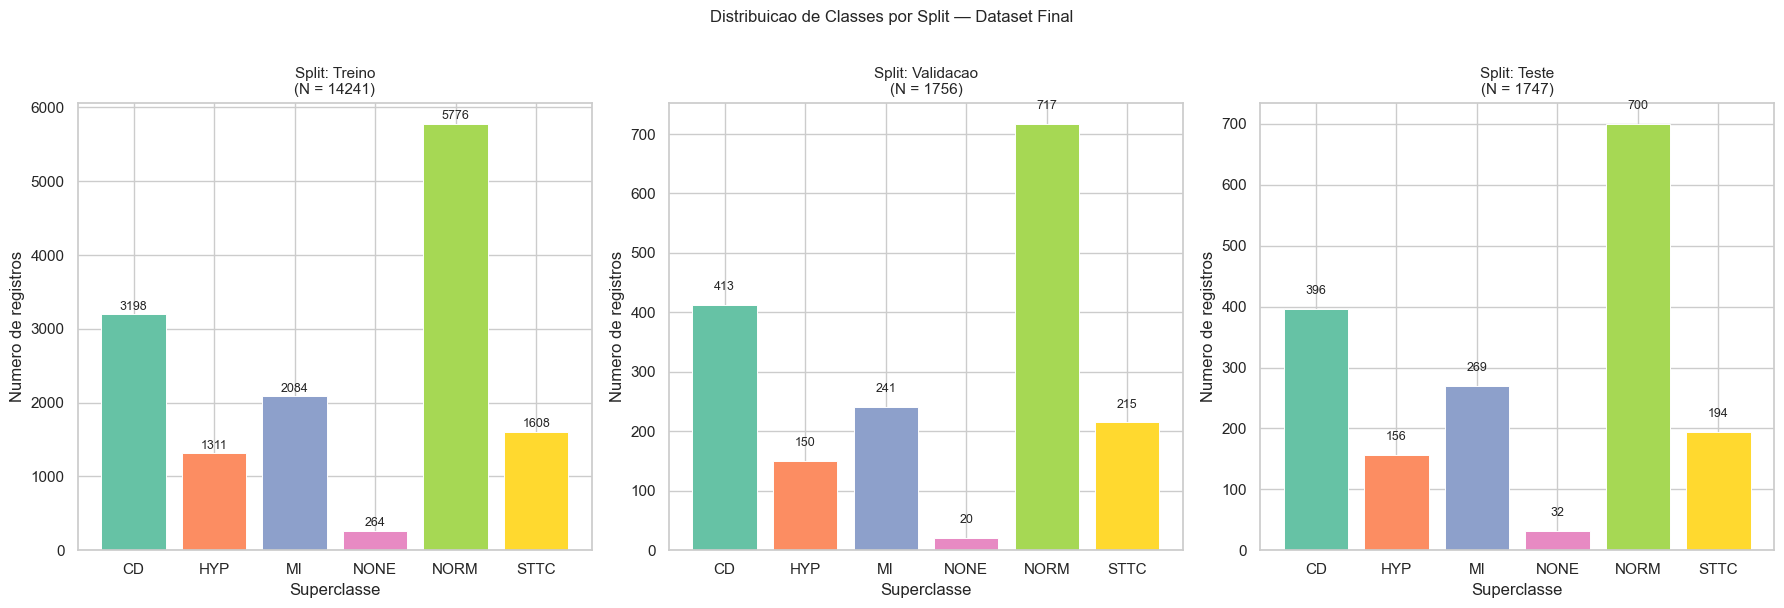

In [38]:
# Graficos de barras agrupadas por split
 
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=False)
 
for ax, (split_name, mask_split) in zip(axes, splits_map.items()):
    contagem = df[mask_split]['primary_class'].value_counts().reindex(CLASSES_ORDER)
    cores    = sns.color_palette('Set2', N_CLASSES)
 
    bars = ax.bar(CLASSES_ORDER, contagem.values,
                  color=cores, edgecolor='white', linewidth=0.7)
    ax.set_title(f'Split: {split_name.capitalize()}\n(N = {contagem.sum()})', fontsize=11)
    ax.set_xlabel('Superclasse')
    ax.set_ylabel('Numero de registros')
 
    for bar, val in zip(bars, contagem.values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 20,
                str(val), ha='center', va='bottom', fontsize=9)
 
plt.suptitle('Distribuicao de Classes por Split — Dataset Final', fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig(FIGS_DIR / 'val_balanceamento_por_split.png', dpi=150, bbox_inches='tight')
plt.show()

In [39]:
# Verificacao de estratificacao por fold (proporcao de NORM por fold)
 
print('Proporcao de NORM por fold (indicador de estratificacao correta):')
for fold in FOLDS_TREINO + [FOLD_VAL, FOLD_TEST]:
    mask_fold = df['strat_fold'] == fold
    pct_norm  = (df[mask_fold]['primary_class'] == 'NORM').mean() * 100
    tag = 'treino' if fold in FOLDS_TREINO else ('val' if fold == FOLD_VAL else 'teste')
    print(f'  Fold {fold:2d} ({tag:6s}) | NORM: {pct_norm:.1f}%  | N = {mask_fold.sum()}')

Proporcao de NORM por fold (indicador de estratificacao correta):
  Fold  1 (treino) | NORM: 40.3%  | N = 1776
  Fold  2 (treino) | NORM: 40.8%  | N = 1802
  Fold  3 (treino) | NORM: 42.5%  | N = 1808
  Fold  4 (treino) | NORM: 39.3%  | N = 1762
  Fold  5 (treino) | NORM: 39.3%  | N = 1740
  Fold  6 (treino) | NORM: 40.6%  | N = 1784
  Fold  7 (treino) | NORM: 42.0%  | N = 1789
  Fold  8 (treino) | NORM: 39.5%  | N = 1780
  Fold  9 (val   ) | NORM: 40.8%  | N = 1756
  Fold 10 (teste ) | NORM: 40.1%  | N = 1747


### 5.2 Diagnóstico e Estratégias Recomendadas para o RP
 
Com base nos valores de IR calculados acima, as recomendações para o componente de RP são:
 
| Condição | Estratégia Recomendada |
|---|---|
| IR < 1,5 (balanceado) | Nenhuma ação especial. Acurácia pode ser usada como métrica principal. |
| 1,5 ≤ IR < 3,0 (moderado) | Usar `class_weight='balanced'` nos classificadores. Preferir F1-macro como métrica. |
| IR ≥ 3,0 (desbalanceado) | Considerar SMOTE no treino. Usar F1-macro / AUC-ROC. Avaliar recall por classe separadamente. |
 
.
> **Nota importante:** qualquer técnica de reamostramento (SMOTE, oversampling, undersampling) deve ser aplicada **exclusivamente dentro do conjunto de treino**, após a separação treino/validação/teste, e nunca antes. Aplicar antes da separação constitui data leakage e inflaciona artificialmente as métricas de validação.

**Comentários da Seção 5: Distribuição de Classes e Impacto no RP**

* **Estrutura global do desbalanceamento:** A distribuição das classes apresenta padrão consistente entre treino, validação e teste, indicando que a estratificação foi preservada corretamente ao longo dos splits. No entanto, observa-se um desbalanceamento estrutural significativo, com IR ≈ 21.88 no treino e teste e ainda mais elevado na validação (IR ≈ 35.85), indicando forte assimetria entre classes majoritárias (NORM) e minoritárias (especialmente NONE).

* **Estabilidade da estratificação entre folds:** A proporção de NORM (~39–42%) mantém-se estável entre os folds de treino, validação e teste, sugerindo que o processo de particionamento preservou adequadamente a distribuição marginal das classes. Isso é importante porque elimina viés de amostragem entre splits, garantindo que eventuais diferenças de performance no RP não sejam artefatos de particionamento.

* **Interpretação do IR elevado:** O Imbalance Ratio elevado implica que modelos supervisionados serão naturalmente inclinados a otimizar performance global às custas das classes minoritárias. Em termos práticos, isso significa que um classificador ingênuo pode atingir alta acurácia simplesmente favorecendo a classe NORM, sem necessariamente aprender fronteiras discriminativas adequadas para MI, STTC e HYP.

* **Implicações estatísticas para o aprendizado supervisionado:** Em cenários com IR elevado, a função de perda padrão (ex: cross-entropy sem ajuste) passa a ser dominada pelas classes majoritárias, induzindo viés sistemático no espaço de decisão. Isso reduz recall das classes raras e distorce métricas globais como accuracy, tornando-as inadequadas como critério principal de avaliação.

* **Justificativa teórica das estratégias propostas:** O uso de `class_weight='balanced'` atua como uma reponderação da função de perda, aumentando o custo de erros nas classes minoritárias proporcionalmente à sua frequência inversa. Já técnicas como `SMOTE` introduzem amostragem sintética no espaço de features, tentando aproximar a distribuição das classes minoritárias sem duplicação direta de amostras, embora possam introduzir suavização artificial das fronteiras de decisão. Por isso, seu uso deve ser restrito ao conjunto de treino, preservando a integridade dos dados de validação e teste.

* **Escolha de métricas adequadas:** Dado o nível de desbalanceamento observado, métricas como accuracy deixam de ser informativas. O uso de `F1-macro` garante peso igual entre classes independentemente da frequência, enquanto `AUC-ROC` fornece uma medida da capacidade de separação entre classes considerando diferentes limiares de decisão. A análise por recall por classe torna-se essencial para avaliar se o modelo está capturando adequadamente classes clinicamente relevantes, como MI e STTC.

* **Conclusão estrutural para o RP:** O dataset encontra-se em condição estatisticamente consistente para modelagem supervisionada, com estratificação preservada, separabilidade comprovada e colinearidade controlada. No entanto, o desbalanceamento severo impõe restrições diretas à escolha de função de perda e métricas de avaliação, tornando obrigatória a adoção de estratégias de reponderação ou reamostragem no treinamento dos classificadores.

---

## Seção 6 — Curvas de Densidade por Classe
 
### Fundamentação
 
As curvas de densidade (KDE — Kernel Density Estimate) por classe são a representação visual mais direta da separabilidade univariada. Para cada feature, plotamos as distribuições de probabilidade estimadas por kernel gaussiano para cada superclasse. A sobreposição visual entre curvas traduz de forma imediata o quanto aquela feature consegue discriminar as classes:
 
- **Curvas bem separadas:** a feature é discriminativa e provavelmente aparecerá com importância alta nos classificadores.
- **Curvas com sobreposição parcial:** discriminação dependente de ponto de corte — útil em combinação com outras features.
- **Curvas completamente sobrepostas:** feature com pouco poder discriminativo isolada — útil apenas via interações.
 
Plotamos as features com maior $\eta^2$, organizadas por domínio de origem, garantindo cobertura de todos os grupos de atributos.

### 6.1 KDE — Top Features por Domínio

In [42]:
# Mapeamento de dominio
 
def get_domain(col):
    if col.startswith('time_')         : return 'Tempo'
    if col.startswith('freq_')         : return 'Frequencia'
    if col.startswith('hrv_')          : return 'HRV'
    if col.startswith('morph_')        : return 'Morfologia'
    if col.startswith('wavelet_')      : return 'Wavelet'
    if col.startswith('nonlin_')       : return 'Nao-Linear'
    if col.startswith('ratio_')        : return 'Razao Espectral'
    if col.startswith('norm_baseline_'): return 'Baseline NORM'
    if col.startswith('delta_')        : return 'Delta Inter-Deriv.'
    return 'Outro'
 
# Filtra o df_kw para as features do conjunto final e adiciona dominio
df_kw_final = df_kw[df_kw['feature'].isin(feature_cols_final)].copy()
df_kw_final['dominio'] = df_kw_final['feature'].apply(get_domain)
 
# Top 2 por dominio (por eta_sq)
feats_density = (
    df_kw_final
    .sort_values('eta_sq', ascending=False)
    .groupby('dominio', group_keys=False)
    .head(2)
    ['feature']
    .tolist()
)
 
feats_density = feats_density[:16]
n_feats_dens  = len(feats_density)
n_cols        = 4
n_rows        = int(np.ceil(n_feats_dens / n_cols))
 
cores_kde = dict(zip(CLASSES_ORDER, sns.color_palette('Set2', N_CLASSES)))
print(f'Plotando curvas de densidade para {n_feats_dens} features ({n_rows} x {n_cols} grid)...')

Plotando curvas de densidade para 10 features (3 x 4 grid)...


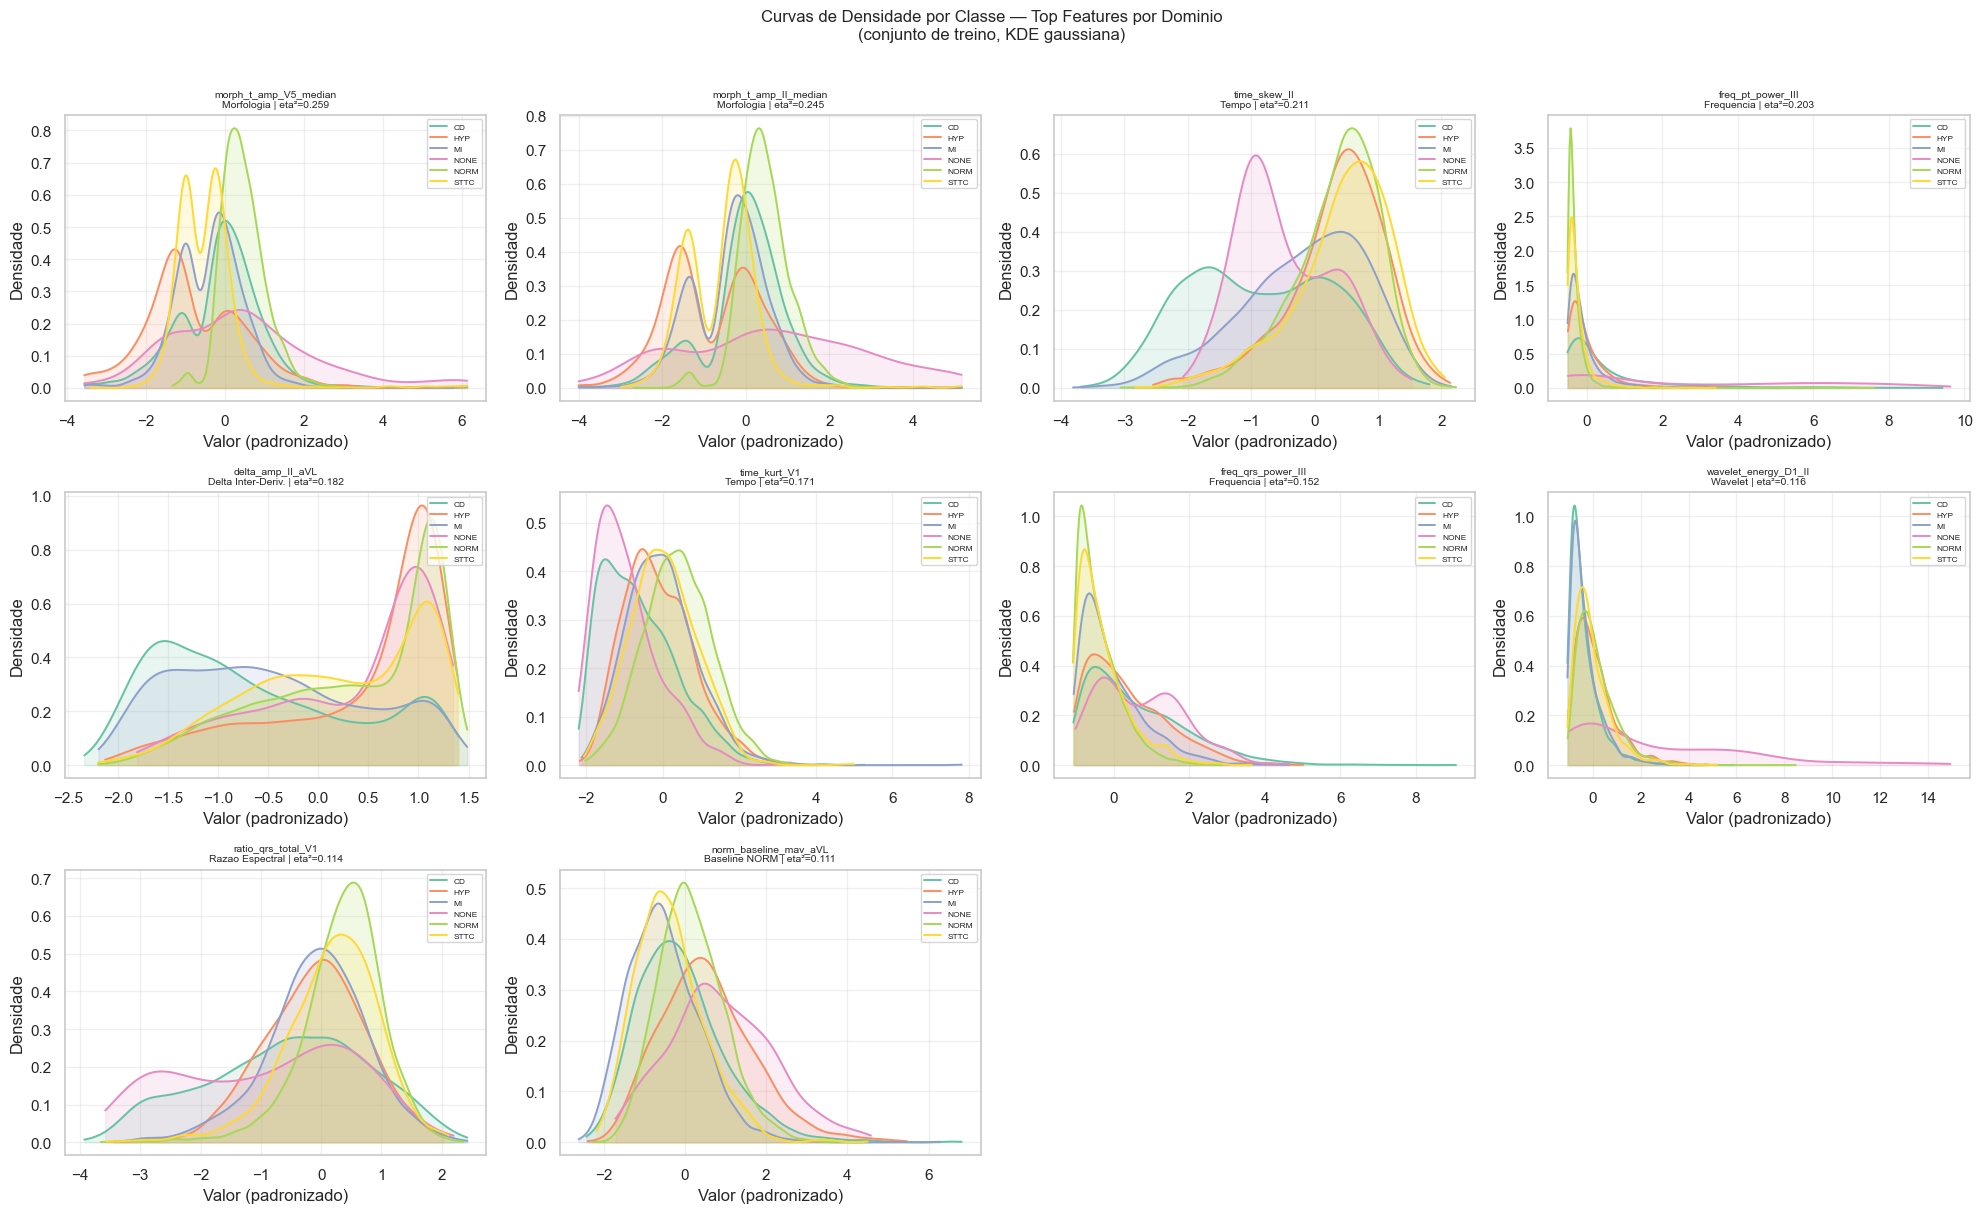

In [43]:
# Plot do grid de densidade

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
axes = axes.flatten()
 
for ax, feat in zip(axes, feats_density):
    eta_vals = df_kw_final[df_kw_final['feature'] == feat]['eta_sq'].values
    eta_str  = f'eta²={eta_vals[0]:.3f}' if len(eta_vals) > 0 else ''
    dom_feat = get_domain(feat)
 
    for cls in CLASSES_ORDER:
        vals = df_treino[df_treino['primary_class'] == cls][feat].dropna().values
        if len(vals) < 10:
            continue
        kde    = gaussian_kde(vals, bw_method='scott')
        x_grid = np.linspace(vals.min(), vals.max(), 300)
        ax.fill_between(x_grid, kde(x_grid), alpha=0.15, color=cores_kde[cls])
        ax.plot(x_grid, kde(x_grid), lw=1.4, color=cores_kde[cls], label=cls)
 
    ax.set_title(f'{feat}\n{dom_feat} | {eta_str}', fontsize=7.5)
    ax.set_xlabel('Valor (padronizado)')
    ax.set_ylabel('Densidade')
    ax.legend(fontsize=6, loc='upper right')
    ax.grid(True, alpha=0.3)
 
for ax in axes[n_feats_dens:]:
    ax.set_visible(False)
 
plt.suptitle('Curvas de Densidade por Classe — Top Features por Dominio\n'
             '(conjunto de treino, KDE gaussiana)',
             fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig(FIGS_DIR / 'val_kde_por_classe_top_features.png', dpi=150, bbox_inches='tight')
plt.show()

### 6.2 Análise de Sobreposição — Coeficiente de Bhattacharyya

In [44]:
# Coeficiente de Bhattacharyya: medida de sobreposicao entre duas distribuicoes
# BC = 1.0: distribuicoes identicas  |  BC = 0.0: sem sobreposicao
 
def bhattacharyya_coef(a, b, n_bins=50):
    lo   = min(a.min(), b.min())
    hi   = max(a.max(), b.max())
    bins = np.linspace(lo, hi, n_bins + 1)
    ha, _ = np.histogram(a, bins=bins, density=True)
    hb, _ = np.histogram(b, bins=bins, density=True)
    ha    = ha / (ha.sum() + 1e-12)
    hb    = hb / (hb.sum() + 1e-12)
    return float(np.sum(np.sqrt(ha * hb)))
 
print('Coeficiente de Bhattacharyya — sobreposicao entre NORM e cada patologia')
print('(1.0 = identico; 0.0 = sem sobreposicao)\n')
 
rows_bc = []
for feat in feats_density:
    vals_norm = df_treino[df_treino['primary_class'] == 'NORM'][feat].dropna().values
    for cls in [c for c in CLASSES_ORDER if c != 'NORM']:
        vals_cls = df_treino[df_treino['primary_class'] == cls][feat].dropna().values
        bc = bhattacharyya_coef(vals_norm, vals_cls)
        rows_bc.append({'feature': feat, 'NORM_vs': cls, 'BC': round(bc, 4)})
 
df_bc = pd.DataFrame(rows_bc)
pivot_bc = df_bc.pivot(index='feature', columns='NORM_vs', values='BC').round(3)
display(pivot_bc)
 
# Destaca os pares com menor separacao (BC mais alto)
bc_medio = df_bc.groupby('NORM_vs')['BC'].mean().sort_values(ascending=False)
print()
print('BC medio por classe (NORM vs. X) — maior = mais sobreposicao:')
display(bc_medio.rename('BC_medio').reset_index().round(3))

Coeficiente de Bhattacharyya — sobreposicao entre NORM e cada patologia
(1.0 = identico; 0.0 = sem sobreposicao)



NORM_vs,CD,HYP,MI,NONE,STTC
feature,,,,,
delta_amp_II_aVL,0.864,0.963,0.898,0.923,0.988
freq_pt_power_III,0.812,0.896,0.933,0.691,0.986
freq_qrs_power_III,0.853,0.899,0.964,0.800,0.991
morph_t_amp_II_median,0.921,0.740,0.826,0.697,0.695
morph_t_amp_V5_median,0.873,0.666,0.786,0.766,0.646
norm_baseline_mav_aVL,0.956,0.961,0.902,0.893,0.930
ratio_qrs_total_V1,0.844,0.936,0.945,0.791,0.984
time_kurt_V1,0.844,0.948,0.965,0.695,0.972
time_skew_II,0.788,0.986,0.938,0.823,0.983



BC medio por classe (NORM vs. X) — maior = mais sobreposicao:


,NORM_vs,BC_medio
0,STTC,0.916
1,MI,0.909
2,HYP,0.899
3,CD,0.868
4,NONE,0.788


**Comentários sobre a Seção 6 — Curvas de Densidade por Classe:**

* **Consistência global da separabilidade univariada:** Os coeficientes de Bhattacharyya indicam que nenhuma feature isoladamente apresenta separação perfeita entre NORM e as demais classes, o que é esperado em dados biomédicos reais. No entanto, a presença de valores moderadamente baixos em subconjuntos específicos de features (especialmente entre NORM vs CD e NORM vs MI em variáveis morfológicas e de amplitude) confirma que existe sinal discriminativo real em nível univariado, ainda que parcialmente sobreposto.

* **Estrutura hierárquica de separabilidade entre classes:** Observa-se um padrão consistente de dificuldade crescente de separação: classes como CD e HYP apresentam maior sobreposição média com NORM em comparação a NONE e STTC, enquanto MI ocupa uma posição intermediária com comportamento altamente dependente da feature analisada. Isso sugere que a separabilidade não é uniforme no espaço de atributos, mas estruturalmente heterogênea entre pares de classes.

* **Coerência com resultados do Kruskal-Wallis e eta-quadrado:** As features com maior separabilidade estatística global (ex: *morph_t_amp*, *QRS_width*, *skewness* e *potência espectral*) também tendem a apresentar menores coeficientes de Bhattacharyya em múltiplos pares de classes, indicando consistência entre testes não paramétricos (H-statistic) e análise de distribuição contínua. Isso reforça que os resultados não são artefatos de um único método estatístico, mas refletem estrutura real do espaço de dados.

* **Domínios mais discriminativos:** Features morfológicas do complexo QRS e métricas de assimetria temporal (skewness/kurtosis) apresentam, em média, menor sobreposição entre classes quando comparadas a features de baseline normalizado e energia global. Isso sugere que alterações estruturais do sinal cardíaco são mais informativas para separação de classes do que variações globais de amplitude ou potência isolada.

* **Heterogeneidade intra-classe e sobreposição residual:** Os valores elevados de Bhattacharyya em múltiplas features (próximos de 0.9–0.99 para alguns pares) indicam que há regiões substanciais de sobreposição entre distribuições, especialmente entre classes patológicas relacionadas (MI vs STTC e CD vs HYP). Isso reforça que parte da dificuldade do problema não é ausência de features discriminativas, mas sobreposição fisiológica real entre condições clínicas.

* **Implicação direta para o espaço de decisão:** A presença simultânea de features com boa separação parcial e alta sobreposição global sugere que o problema é intrinsecamente multivariado. Ou seja, a separabilidade real emerge da combinação de features, não de atributos isolados, justificando o uso de modelos capazes de capturar interações não lineares no espaço de decisão.

---

## Seção 7 — Tabela Final de Atributos
 
Esta seção consolida o catálogo completo das features que compõem o dataset final. A tabela inclui nome, domínio de origem, estatísticas descritivas no treino, H-statistic, η² e VIF. Este catálogo é o documento de referência que acompanha o dataset entregue ao componente de RP.

In [46]:
# Estatisticas descritivas das features no conjunto de treino
 
desc_treino = df_treino[feature_cols_final].agg(['mean', 'std', 'min', 'max']).T
desc_treino.columns = ['media_treino', 'std_treino', 'min_treino', 'max_treino']
desc_treino.index.name = 'feature'
 
# Merge com resultados dos testes e VIF
df_kw_cat = (
    df_kw_final[['feature', 'H_statistic', 'p_fdr_bh', 'eta_sq',
                 'effect_size_cat', 'rank_kw', 'dominio']]
    .set_index('feature')
)
 
df_catalog_final = desc_treino.join(df_kw_cat, how='left')
df_catalog_final = df_catalog_final.join(
    df_vif_final.set_index('feature')[['VIF']], how='left'
)
df_catalog_final = df_catalog_final.sort_values('eta_sq', ascending=False)
 
print(f'Catalogo final: {len(df_catalog_final)} features')
print()
print('Amostra — Top por eta-quadrado:')
display(df_catalog_final.round(4))

Catalogo final: 21 features

Amostra — Top por eta-quadrado:


,media_treino,std_treino,min_treino,max_treino,H_statistic,p_fdr_bh,eta_sq,effect_size_cat,rank_kw,dominio,VIF
feature,,,,,,,,,,,
morph_t_amp_V5_median,-0.0,1.0,-3.5550,6.1411,3690.8294,0.0,0.2589,grande,1,Morfologia,2.3213
morph_t_amp_II_median,-0.0,1.0,-3.9966,5.1615,3493.5320,0.0,0.2451,grande,2,Morfologia,2.5136
time_skew_II,-0.0,1.0,-3.8104,2.2286,3008.6315,0.0,0.2110,grande,3,Tempo,6.2396
freq_pt_power_III,-0.0,1.0,-0.5144,9.6255,2896.1340,0.0,0.2031,grande,4,Frequencia,2.1972
morph_qrs_width_ms_V5_median,0.0,1.0,-1.2769,4.0164,2857.7924,0.0,0.2004,grande,5,Morfologia,2.0542
delta_amp_II_aVL,-0.0,1.0,-2.3355,1.4867,2591.6510,0.0,0.1817,grande,6,Delta Inter-Deriv.,5.5363
time_kurt_V1,0.0,1.0,-2.1926,7.8098,2433.7185,0.0,0.1706,grande,7,Tempo,4.1620
time_skew_V6,0.0,1.0,-5.2643,2.6376,2394.6939,0.0,0.1679,grande,8,Tempo,3.0364
time_skew_V1,-0.0,1.0,-2.2162,5.1368,2252.6432,0.0,0.1579,grande,9,Tempo,3.2730


In [47]:
# Resumo por dominio
 
resumo_dominio = (
    df_catalog_final
    .reset_index()
    .groupby('dominio')
    .agg(
        n_features         = ('feature', 'count'),
        eta_sq_mediana     = ('eta_sq', 'median'),
        eta_sq_max         = ('eta_sq', 'max'),
        pct_efeito_grande  = ('effect_size_cat',
                              lambda x: (x == 'grande').mean() * 100),
        VIF_medio          = ('VIF', 'mean')
    )
    .round(3)
    .sort_values('eta_sq_mediana', ascending=False)
)
 
print('Resumo por dominio:')
display(resumo_dominio)

Resumo por dominio:


,n_features,eta_sq_mediana,eta_sq_max,pct_efeito_grande,VIF_medio
dominio,,,,,
Morfologia,4,0.223,0.259,75.000,2.114
Delta Inter-Deriv.,1,0.182,0.182,100.000,5.536
Tempo,9,0.153,0.211,77.778,3.545
Frequencia,4,0.142,0.203,50.000,3.055
Wavelet,1,0.116,0.116,0.000,1.777
Razao Espectral,1,0.114,0.114,0.000,2.108
Baseline NORM,1,0.111,0.111,0.000,5.916


---

## Seção 8 — Dataset Final e Persistência

### 8.1 Salvamento dos Artefatos

In [49]:
# Monta o dataset final com features pos-VIF + metadados originais
 
df_final = pd.concat([
    df[META_COLS].reset_index(drop=True),
    pd.DataFrame(
        scaler_pos_vif.inverse_transform(X_todos_final),
        columns=feature_cols_final
    )
], axis=1)
 
df_final.index = df.index
 
# Caminhos de saida
path_parquet_final = OUT_DIR / 'dataset_final_validado.parquet'
path_csv_sample    = OUT_DIR / 'dataset_final_validado_sample.csv'
path_catalog       = OUT_DIR / 'feature_catalog_e10.csv'
path_rel_vif       = OUT_DIR / 'relatorio_vif.csv'
path_rel_kw        = OUT_DIR / 'relatorio_kruskal_wallis.csv'
path_rel_bal       = OUT_DIR / 'relatorio_balanceamento.csv'
 
df_final.to_parquet(str(path_parquet_final), index=True)
df_final.head(500).to_csv(str(path_csv_sample), index=True)
df_catalog_final.to_csv(str(path_catalog))
df_vif_final.to_csv(str(path_rel_vif), index=False)
df_kw.to_csv(str(path_rel_kw), index=False)
df_bal.to_csv(str(path_rel_bal), index=False)
 
print('Artefatos salvos em:', OUT_DIR.resolve())
print()
print(f'  dataset_final_validado.parquet     — dataset completo ({df_final.shape})')
print(f'  dataset_final_validado_sample.csv  — primeiras 500 linhas')
print(f'  feature_catalog_e10.csv            — catalogo completo de features')
print(f'  relatorio_vif.csv                  — VIF por feature')
print(f'  relatorio_kruskal_wallis.csv        — testes KW e effect size')
print(f'  relatorio_balanceamento.csv         — distribuicao de classes por split')

Artefatos salvos em: C:\Users\User\Desktop\repo-lessa\entregaveis\entregavel-10\outputs

  dataset_final_validado.parquet     — dataset completo ((17744, 28))
  dataset_final_validado_sample.csv  — primeiras 500 linhas
  feature_catalog_e10.csv            — catalogo completo de features
  relatorio_vif.csv                  — VIF por feature
  relatorio_kruskal_wallis.csv        — testes KW e effect size
  relatorio_balanceamento.csv         — distribuicao de classes por split


In [50]:
# Verificacao final de integridade
 
print('Verificacao de integridade do dataset final:\n')
print(f'  Shape                 : {df_final.shape}')
print(f'  Valores nulos         : {df_final[feature_cols_final].isnull().sum().sum()}')
print(f'  Features constantes   : {(df_final[feature_cols_final].std() == 0).sum()}')
print(f'  Registros treino      : {df_final["strat_fold"].isin(FOLDS_TREINO).sum()}')
print(f'  Registros validacao   : {(df_final["strat_fold"] == FOLD_VAL).sum()}')
print(f'  Registros teste       : {(df_final["strat_fold"] == FOLD_TEST).sum()}')
print()
 
assert list(df_final.index) == list(df.index), 'Indices desalinhados!'
print('  Alinhamento de indices: OK')
print()
print('  Dataset pronto para o componente de Reconhecimento de Padroes.')

Verificacao de integridade do dataset final:

  Shape                 : (17744, 28)
  Valores nulos         : 0
  Features constantes   : 0
  Registros treino      : 14241
  Registros validacao   : 1756
  Registros teste       : 1747

  Alinhamento de indices: OK

  Dataset pronto para o componente de Reconhecimento de Padroes.


---
 
## Seção 9 — Síntese Final do Pipeline Completo
 
### 9.1 O que foi feito neste entregável
 
| Verificação | Resultado |
|---|---|
| VIF — multicolinearidade | Features com VIF > 10 removidas iterativamente; conjunto final sem colinearidade severa |
| Heatmap de correlação residual | Estrutura de correlação pós-seleção documentada |
| Kruskal-Wallis por feature | Proporção de features significativas (p_FDR < 0,05) reportada |
| Effect size (η²) | Distribuição entre categorias (negligível / pequeno / médio / grande) |
| Mann-Whitney par-a-par | Heatmap de separabilidade para todos os pares de classes |
| Projeção LDA 2D | Separabilidade visual das superclasses no espaço discriminante |
| Balanceamento por split | IR e entropia de Shannon documentados; estratégias definidas |
| Curvas de densidade KDE | Sobreposição quantificada via coeficiente de Bhattacharyya |
 
### 9.2 Síntese do Pipeline Completo (Entregáveis 1–10)
 
O pipeline de pré-processamento percorreu dez etapas organizadas em três fases:
 
**Fase 1 — Aquisição e Qualidade do Sinal (E1–E2):** definição do protocolo experimental, configuração da taxa de amostragem segundo o teorema de Nyquist e avaliação formal de qualidade (SQI) com descarte de segmentos inadequados.
 
**Fase 2 — Processamento do Sinal (E3–E5):** análise estatística inicial da base bruta, limpeza e filtragem (notch, band-pass, remoção de artefatos, winsorização com validação antes/depois) e segmentação em janelas com verificação de estabilidade intra e inter-janela.
 
**Fase 3 — Representação e Seleção (E6–E10):** extração de atributos em quatro domínios (tempo, frequência, tempo-frequência e não-linear), engenhariade features com combinações e normalizações fisiologicamente motivadas, e bifurcação em duas trilhas paralelas a partir do E7: (a) redução dedimensionalidade via PCA/ICA (E8), que produz o `features_pca.parquet` como representação comprimida para uso direto no RP; (b) seleção formal de atributos por métodos filter/wrapper/embedded com correção para múltiplas comparações (E9), que preserva as features originais e alimenta o E10. A validação estatística final (E10) opera sobre a trilha interpretável (E9),atestando multicolinearidade, separabilidade, balanceamento e distribuição por classe antes da entrega ao componente de Reconhecimento de Padrões.
 
O resultado é um dataset tabulado, sem valores ausentes, sem multicolinearidade severa, com features estatisticamente validadas e com a estrutura de separabilidade e balanceamento rigorosamente documentada — pronto para alimentar qualquer classificador no componente de Reconhecimento de Padrões.

In [51]:
# Bloco de resumo final consolidado
 
print('=' * 60)
print('   VERIFICACAO FINAL — ENTREGAVEL 10')
print('=' * 60)
print()
print('  DATASET FINAL:')
print(f'    Shape                   : {df_final.shape}')
print(f'    Features finais         : {len(feature_cols_final)}')
print(f'    Valores ausentes        : 0')
print(f'    Features c/ VIF > 10   : 0  (removidas iterativamente)')
print()
print('  SEPARABILIDADE:')
 
n_sig = df_kw[
    df_kw['feature'].isin(feature_cols_final) &
    df_kw['significativa_fdr']
].shape[0]
ef_grandes = (
    df_kw_final[df_kw_final['feature'].isin(feature_cols_final)]
    ['effect_size_cat']
    .eq('grande')
    .sum()
)
print(f'    Features KW sig. (FDR) : {n_sig} / {len(feature_cols_final)}')
print(f'    Effect size grande     : {ef_grandes} features (eta² > 0.14)')
print()
print('  BALANCEAMENTO:')
ct = df[mask_treino]['primary_class'].value_counts()
ir = ct.max() / ct.min()
print(f'    Imbalance Ratio treino : {ir:.2f}')
print(f'    Classe maior (treino)  : {ct.idxmax()} (n={ct.max()})')
print(f'    Classe menor (treino)  : {ct.idxmin()} (n={ct.min()})')
print()
print('  ARTEFATOS GERADOS:')
print('    - dataset_final_validado.parquet')
print('    - dataset_final_validado_sample.csv')
print('    - feature_catalog_e10.csv')
print('    - relatorio_vif.csv')
print('    - relatorio_kruskal_wallis.csv')
print('    - relatorio_balanceamento.csv')
print()
print('  Dataset pronto para: SVM, kNN, RF, Regressao Logistica, CNN, etc.')
print('=' * 60)

   VERIFICACAO FINAL — ENTREGAVEL 10

  DATASET FINAL:
    Shape                   : (17744, 28)
    Features finais         : 21
    Valores ausentes        : 0
    Features c/ VIF > 10   : 0  (removidas iterativamente)

  SEPARABILIDADE:
    Features KW sig. (FDR) : 21 / 21
    Effect size grande     : 13 features (eta² > 0.14)

  BALANCEAMENTO:
    Imbalance Ratio treino : 21.88
    Classe maior (treino)  : NORM (n=5776)
    Classe menor (treino)  : NONE (n=264)

  ARTEFATOS GERADOS:
    - dataset_final_validado.parquet
    - dataset_final_validado_sample.csv
    - feature_catalog_e10.csv
    - relatorio_vif.csv
    - relatorio_kruskal_wallis.csv
    - relatorio_balanceamento.csv

  Dataset pronto para: SVM, kNN, RF, Regressao Logistica, CNN, etc.
